In [17]:
import os
import re
import nltk
from nltk import Tree

import spacy
# spacy.cli.download("nl_core_news_lg")
nlp = spacy.load("nl_core_news_lg") 

import pandas as pd
import numpy as np

import textdescriptives as td

from dataset_evaluation.utils import add_column
from dataset_evaluation.evaluation_framework import EvaluationFramework

import folia.main as folia
from pathlib import Path
from collections import defaultdict, Counter
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
from datasets import load_dataset

import pylangacq
import ast
from matplotlib.lines import Line2D
from matplotlib import cm, colors as mcolors

from diversity import (
    compression_ratio,
    homogenization_score
)
from vendi_score import text_utils
import seaborn as sns
from typing import List

from scipy.stats import stats

from readability import Readability
from sentence_transformers import SentenceTransformer

plt.style.use("seaborn-v0_8-whitegrid")

# Datasets

In [2]:
# generated corpus
first_prompting = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/prompting/prompt_results.csv')

## Generated corpus (tinystories translated)

In [3]:
# generated corpus
tinystories_dutch = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/TinyStories/tinystories_part_dutch.csv')

## Age related prompts

In [9]:
age_gemma = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/prompting/prompting_results/age_research_DD_gemma3-27b.csv')
age_gemma.drop(columns=['Unnamed: 0'])

     Unnamed: 0                       model    age  \
0             0  google/gemma-3-27b-it-fast    4_6   
1             1  google/gemma-3-27b-it-fast    4_6   
2             2  google/gemma-3-27b-it-fast    4_6   
3             3  google/gemma-3-27b-it-fast    4_6   
4             4  google/gemma-3-27b-it-fast    4_6   
..          ...                         ...    ...   
383         383  google/gemma-3-27b-it-fast  11_12   
384         384  google/gemma-3-27b-it-fast  11_12   
385         385  google/gemma-3-27b-it-fast  11_12   
386         386  google/gemma-3-27b-it-fast  11_12   
387         387  google/gemma-3-27b-it-fast  11_12   

                                                 story  
0    Eén keer… eh… was ik op vakantie! Bij oma en o...  
1    En toen… toen ging ik met mijn opa naar het bo...  
2    Eéns… was er een hele grote beer. Niet zomaar ...  
3    Oké, luister goed!\n\nEr was eens een kleine r...  
4    Oké, luister! Er was eens een hele kleine eend...  
..       

,model,age,story
0,google/gemma-3-27b-it-fast,4_6,Eén keer… eh… was ik op vakantie! Bij oma en o...
1,google/gemma-3-27b-it-fast,4_6,En toen… toen ging ik met mijn opa naar het bo...
2,google/gemma-3-27b-it-fast,4_6,Eéns… was er een hele grote beer. Niet zomaar ...
3,google/gemma-3-27b-it-fast,4_6,"Oké, luister goed!\n\nEr was eens een kleine r..."
4,google/gemma-3-27b-it-fast,4_6,"Oké, luister! Er was eens een hele kleine eend..."
...,...,...,...
383,google/gemma-3-27b-it-fast,11_12,"Dus, gisteren… gisteren was echt raar. Ik was ..."
384,google/gemma-3-27b-it-fast,11_12,"Dus, gisteren… gisteren was echt raar. Ik fiet..."
385,google/gemma-3-27b-it-fast,11_12,"Nou, het gebeurde vorige zomer, bij oma. Oma w..."
386,google/gemma-3-27b-it-fast,11_12,"Nou, het begon allemaal met een oude sleutel. ..."


## Age related llama

In [10]:
age_llama = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/prompting/prompting_results/age_research_DD_llama3-8b.csv')
age_llama.drop(columns=['Unnamed: 0'])

,model,age,story
0,meta-llama/llama-3.1-8b-instruct,4_6,Er was eens een prinses met een paard dat groe...
1,meta-llama/llama-3.1-8b-instruct,4_6,Er was eens een prinses die een prachtig paard...
2,meta-llama/llama-3.1-8b-instruct,4_6,"Een tijdje geleden, in een klein dorpje met ee..."
3,meta-llama/llama-3.1-8b-instruct,4_6,Er was eens een kleine roodharige koningin. Ze...
4,meta-llama/llama-3.1-8b-instruct,4_6,Er was eens een konijn met een prachtige lange...
...,...,...,...
373,meta-llama/llama-3.1-8b-instruct,11_12,We waren op schoolreis naar het strand. We had...
374,meta-llama/llama-3.1-8b-instruct,11_12,Een keer was ik op vakantie bij oma en opa in ...
375,meta-llama/llama-3.1-8b-instruct,11_12,We hadden allemaal zomervakantie en ik ging me...
376,meta-llama/llama-3.1-8b-instruct,11_12,Er was eens een schattig konijntje dat in een ...


In [38]:
age_improved_llama = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/prompting/prompting_results/age_research_ellaborateprompt_DD_llama3-8b.csv')
age_improved_llama.drop(columns=['Unnamed: 0'])


,model,age,story
0,meta-llama/llama-3.1-8b-instruct,4_6,Er was een keer een hond. Hij heette Max. Hij ...
1,meta-llama/llama-3.1-8b-instruct,4_6,Er was een prinses met een prachtig paard. Ze ...
2,meta-llama/llama-3.1-8b-instruct,4_6,Er was eens een prinsesje. Ze heette Sophia en...
3,meta-llama/llama-3.1-8b-instruct,4_6,"Er waren eens twee konijnen, Hopske en Kriebel..."
4,meta-llama/llama-3.1-8b-instruct,4_6,Er was eens een konijntje. Dat konijntje heett...
...,...,...,...
345,meta-llama/llama-3.1-8b-instruct,11_12,Er was eens een prinsesje genaamd Sophia. Zij ...
346,meta-llama/llama-3.1-8b-instruct,11_12,Er was eens een meisje dat heette Sophia. Ze w...
347,meta-llama/llama-3.1-8b-instruct,11_12,Er was eens een hond genaamd Max. Hij was een ...
348,meta-llama/llama-3.1-8b-instruct,11_12,Er was eens een hond genaamd Max. Hij was een ...


In [39]:
age_improved_gemma = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/prompting/prompting_results/age_research_ellaborateprompt_DD_gemma3-27b.csv')
age_improved_gemma.drop(columns=['Unnamed: 0'])

,model,age,story
0,google/gemma-3-27b-it-fast,4_6,Eén keer was er een hele grote beer. Die beer ...
1,google/gemma-3-27b-it-fast,4_6,Er was eens een blauwe olifant. Die woonde in ...
2,google/gemma-3-27b-it-fast,4_6,"Oké, luister goed!\n\nEr was eens een beer, ee..."
3,google/gemma-3-27b-it-fast,4_6,"Oké, luister allemaal!\n\nEr was eens een hele..."
4,google/gemma-3-27b-it-fast,4_6,Eens was er een heel klein muisje. Hij woonde ...
...,...,...,...
345,google/gemma-3-27b-it-fast,11_12,"Oké, luister dan. Mijn buurman, Tim, die heeft..."
346,google/gemma-3-27b-it-fast,11_12,"Oké, luister! Het gaat over meneer Pietersen, ..."
347,google/gemma-3-27b-it-fast,11_12,"Oké, luister dan.\n\nMijn buurvrouw, mevrouw J..."
348,google/gemma-3-27b-it-fast,11_12,"Oké, luister even. Het gaat over opa Pieter en..."


## Prompting -- Narative elements

In [64]:
narrative_elements_data = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/prompting/prompting_results/storyelement_research_prompting_llama3-8b.csv')
narrative_elements_data.columns

Index(['model', 'narrative_element', 'system', 'user', 'completion1',
       'completion2', 'completion3', 'completion4', 'completion5'],
      dtype='object')

In [65]:
# columns containing completions
completion_cols = ["completion1", "completion2", "completion3", "completion4", "completion5"]

# ---- case 1: narrative_element == 0 ----
df_zero = (
    narrative_elements_data[narrative_elements_data["narrative_element"] == str(0)][completion_cols]
    .melt(value_name="completion", var_name="completion_number")
    .drop(columns="completion_number")
    .reset_index(drop=True)
)

# ---- case 2: narrative_element != 0 ----
df_nonzero = (
    narrative_elements_data[narrative_elements_data["narrative_element"] != str(0)][["model", "narrative_element", "system", "user"] + completion_cols]
    .melt(id_vars=["model", "narrative_element", "system", "user"],
          value_name="completion",
          var_name="completion_number")
    .drop(columns="completion_number")
    .reset_index(drop=True)
)

# optional: preview
print("=== narrative_element == 0 ===")
print(df_zero.head())
print("\n=== narrative_element != 0 ===")
print(df_nonzero.head())

=== narrative_element == 0 ===
                                          completion
0  Er was eens een prinsesje met een paardje. Het...
1  Er was eens een prinsesje met een rode haardos...
2  Er was eens een prinses die een magische lanta...
3  Er was eens een leuke vogel. Hij heette Pip. P...
4  Er was eens een konijn met een prachtige witte...

=== narrative_element != 0 ===
                              model            narrative_element  \
0  meta-llama/llama-3.1-8b-instruct                in medias res   
1  meta-llama/llama-3.1-8b-instruct               een morele les   
2  meta-llama/llama-3.1-8b-instruct      een onverwachte wending   
3  meta-llama/llama-3.1-8b-instruct  een onbetrouwbare verteller   
4  meta-llama/llama-3.1-8b-instruct               vooruitwijzing   

                                              system  \
0  \nJe bent een verteller van een kort verhaal (...   
1  \nJe bent een verteller van een kort verhaal (...   
2  \nJe bent een verteller van een kort ve

## Prompting -- Themes

In [66]:
theme_data = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/prompting/prompting_results/storytheme_research_prompting_llama3-8b.csv')
theme_data.columns

Index(['model', 'theme', 'system', 'user', 'completion1', 'completion2',
       'completion3', 'completion4', 'completion5'],
      dtype='object')

In [67]:
# columns containing completions
completion_cols = ["completion1", "completion2", "completion3", "completion4", "completion5"]

# ---- case 1: theme == 0 ----
df_zero_theme = (
    theme_data[theme_data["theme"] == str(0)][completion_cols]
    .melt(value_name="completion", var_name="completion_number")
    .drop(columns="completion_number")
    .reset_index(drop=True)
)

# ---- case 2: theme != 0 ----
df_theme = (
    theme_data[theme_data["theme"] != str(0)][["model", "theme", "system", "user"] + completion_cols]
    .melt(id_vars=["model", "theme", "system", "user"],
          value_name="completion",
          var_name="completion_number")
    .drop(columns="completion_number")
    .reset_index(drop=True)
)

## Prompting -- Additional words

In [53]:
awords_data = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/prompting/prompting_results/additionalwords_research_prompting_llama3-8b.csv')
awords_data.columns

Index(['model', 'theme', 'system', 'user', 'completion1', 'completion2',
       'completion3', 'completion4', 'completion5'],
      dtype='object')

In [62]:
# columns containing completions
completion_cols = ["completion1", "completion2", "completion3", "completion4", "completion5"]

# ---- case 1: theme == 0 ----
df_zero_addition = (
    awords_data[awords_data["theme"] == str(0)][completion_cols]
    .melt(value_name="completion", var_name="completion_number")
    .drop(columns="completion_number")
    .reset_index(drop=True)
)

# ---- case 2: theme != 0 ----
df_awords = (
    awords_data[awords_data["theme"] != str(0)][["model", "theme", "system", "user"] + completion_cols]
    .melt(id_vars=["model", "theme", "system", "user"],
          value_name="completion",
          var_name="completion_number")
    .drop(columns="completion_number")
    .reset_index(drop=True)
)

## Prompting -- pos tag

In [68]:
postag_data = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/prompting/prompting_results/fixedpos_research_prompting_llama3-8b.csv')
postag_data.columns

Index(['model', 'theme', 'system', 'user', 'completion1', 'completion2',
       'completion3', 'completion4', 'completion5'],
      dtype='object')

In [69]:
# columns containing completions
completion_cols = ["completion1", "completion2", "completion3", "completion4", "completion5"]

# ---- case 1: theme == 0 ----
df_zero_pos = (
    postag_data[postag_data["theme"] == str(0)][completion_cols]
    .melt(value_name="completion", var_name="completion_number")
    .drop(columns="completion_number")
    .reset_index(drop=True)
)

# ---- case 2: theme != 0 ----
df_pos = (
    postag_data[postag_data["theme"] != str(0)][["model", "theme", "system", "user"] + completion_cols]
    .melt(id_vars=["model", "theme", "system", "user"],
          value_name="completion",
          var_name="completion_number")
    .drop(columns="completion_number")
    .reset_index(drop=True)
)

## Prompting -- Baseline

In [51]:
baseline_data = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/prompting/prompting_results/baseline_research_prompting_llama3-8b.csv')
baseline_data.columns

Index(['model', 'system', 'user', 'completion'], dtype='object')

## Narrative dataset (ChiSCor)

In [2]:
path_name = '/Users/sabijn/Documents/PhD/Datasets/chisor_dataset_all/ChiSCor_CoNLL_paper/csv/ChiSCor_master_df_password/ChiSCor_master_df.csv'
df_chiscor = pd.read_csv(path_name, index_col=0)

## Reference corpus (standard)

In [55]:
ref_standard_dep = Path('datasets/BasiScript/BS_dep_lexicon.csv')
ref_standard_uni = Path('datasets/BasiScript/BS_unigram_lexicon.csv')
ref_standard_bi = Path('datasets/BasiScript/BS_bigram_lexicon.csv')

## Reference corpus (spoken)

In [56]:
ref_spoken_b_csv = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/CGN/CGN_pos_bigram.csv')
ref_spoken_u_csv  = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/CGN/CGN_pos_unigram.csv')
ref_spoken_t_csv = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/CGN/CGN_pos_trigram.csv')

## Reference corpus (written)

In [57]:
ref_written_b_csv = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/BasiScript/BasiScript_pos_bigram.csv')
ref_written_u_csv  = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/BasiScript/BasiScript_pos_unigram.csv')
ref_written_t_csv = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/BasiScript/BasiScript_pos_trigram.csv')

# Evaluations

Linguistic annotations
- Syntactic tree depth per sentence according to the WNU_2022 paper (van Duijn & van Dijk, 2022)
    - Number of dependency arcs between root and leaf node.
- Average no. of complements per utterance
     - Counts (Open) clausal complements
- Sentence complexity (words before the root)
- Lexical diversity
    - Standard TTR (not implemented).  
    Dividing the number of unique tokens (types) by the total number of tokens.  
    Problem with TTR is that it is lower with a large amount of tokens
    - msTTR (mean segmental type-token ratio (TTR)): 
    
    - maTTR (moving average TTR)
    - MTLD (average number of words for which a consecutive TTR is maintained).  
    Measure of Textual Lexical Diversity.
    - MTLD (moving)
    - MTLD (bidirectional)
    - HDD (bidirectional)
- Vendi score
- Dependency constrained perplexity
- Regular perplexity
- Past tense use
- MAUVE (diversity)

In [71]:
eval_f = EvaluationFramework(language='nl',
                              pos_unigram=ref_spoken_u_csv, 
                              pos_bigram=ref_spoken_b_csv,
                              pos_trigram=ref_spoken_t_csv,
                              ref_unigram=ref_standard_uni,
                              ref_bigram=ref_standard_bi,
                              ref_ling_constrained=ref_standard_dep,
                              embedding_model='jegormeister/bert-base-dutch-cased')

In [ ]:
# eval_f = EvaluationFramework(language='nl',
#                               pos_unigram=ref_written_u_csv, 
#                               pos_bigram=ref_written_b_csv,
#                               pos_trigram=ref_written_t_csv,
#                               ref_unigram=ref_standard_uni,
#                               ref_bigram=ref_standard_bi,
#                               ref_ling_constrained=ref_standard_dep,
#                               embedding_model='jegormeister/bert-base-dutch-cased')

## Syntatic tree depth
-- van Duijn & van Dijk (2022)

In [8]:
eval_f.add_pipe('syntactic_depth')

## Average no. of complements per utterance

In [9]:
eval_f.add_pipe('average_components')

## Sentence complexity
-- ChiSCor (2023) - Average number of words before the root

In [10]:
eval_f.add_pipe('wbr_average')

## Lexical diversity
-- ChiSCor (2023)

In [11]:
eval_f.add_pipe('lexical_diversity')

## Dependency distance
-- ChiSCor (2023)

In [18]:
eval_f.add_pipe('dependency_distance')

## Local contextuality

In [13]:
eval_f.add_pipe("local_contextuality")

## Grammaticality

$G(story) = \dfrac{\sum^k_{i=1}(G(s_i))}{k}$, with $s$ a sentence in the story.  
  
$G(sentence) = P(seq) = \log(\sqrt[n]{\prod_{i=1}^n \left( P(K_i) \right)})$.  
  
$P(K_i) = P(t_3t_2t_1) = \lambda_1 \cdot P(t_3|t_1t_2) + \lambda_2 \cdot P(t_3|t_2) + \lambda_3 \cdot P(t_3)$, where  
  
- where $\lambda_1 + \lambda_2 + \lambda_3 = 1$, ($\lambda_1 = 0.5, \lambda_2 = 0.3, \lambda_3 = 0.2 \rightarrow$ vadlapudi (2010))
- $P(t_3|t_1t_2) = \dfrac{f(t_1t_2t_3)}{f(t_1t_2)}$.  
- $P(t_3|t_2) = \dfrac{f(t_2t_3)}{f(t_2)}$.  
- $P(t_3) = \dfrac{f(t_3)}{\sum_{\forall t_i} f(t_i)}$


In [72]:
eval_f.add_pipe('grammaticality')

## Creative perplexity

In [228]:
eval_f.add_pipe('creative_perplexity_unigram')
eval_f.add_pipe('creative_perplexity_bigram')
eval_f.add_pipe('creative_perplexity_bigram_constrained')

## Vendi score
-- [Friedman (2023) The Vendi Score: A Diversity Evaluation Metric for Machine Learning](https://github.com/vertaix/Vendi-Score)

In [93]:
eval_f.add_pipe("vendi_ngram")
eval_f.add_pipe("vendi_embeddings")

## Compression & homogeinity score

In [17]:
from diversity import (
    compression_ratio
)
cr_tinystories = compression_ratio(tinystories_dutch['story_nl'].to_list(), algorithm='gzip')
print(f"Compression Ratio TinyStories: {cr_tinystories:.4f}")

Compression Ratio TinyStories: 3.0340


In [18]:
eval_f.add_pipe("self-bleu")
df_chiscor['self-bleu'] = df_chiscor.apply(lambda row: eval_f.run_component('self-bleu', row['story_raw']), axis = 1) 

(array([454.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 164.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

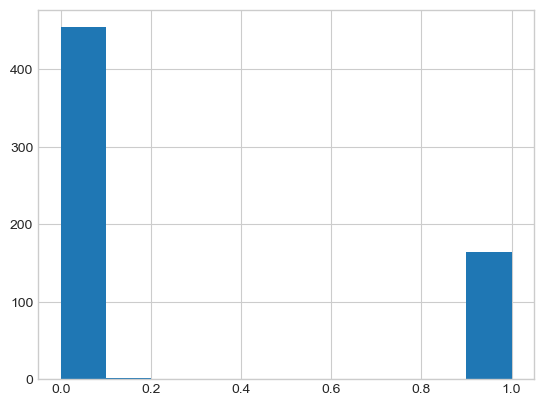

In [21]:
plt.hist(df_chiscor['self-bleu'])

## Lexical complexity

- Average word length
- Average sentence length

## Run pipeline (real data)

In [ ]:
def load_or_run_eval(eval_f, dataset, column, path_name, *, run=False):
    if Path(path_name).exists() and not run:
        df = pd.read_csv(path_name)
        if 'lexical_diversity' in df.columns:
            df['lexical_diversity'] = df['lexical_diversity'].apply(ast.literal_eval)
            
        return df

    dataset = eval_f.run_pipeline_on_df(dataset, column)
    dataset.to_csv(path_name, index=False)
    return dataset

In [ ]:
df_chiscor = load_or_run_eval(eval_f, df_chiscor, 'story_raw_no_newlines', 'results/chiscor_eval_results.csv')

Running syntactic_depth
Running syntactic_depth
Running average_components
Running wbr_average
Running lexical_diversity
Running dependency_distance
Running local_contextuality
Running grammaticality
Running creative_perplexity_unigram
Running creative_perplexity_bigram
Running creative_perplexity_bigram_constrained
Running vendi_ngram


/opt/miniconda3/envs/storylmdata/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Running vendi_embeddings


In [ ]:
df_chiscor['msTTR'] = df_chiscor.apply(lambda row: eval_f.run_component('lexical_diversity', row['story_raw'], methods="msTTR"), axis = 1) 

## Run pipeline (tinystories)

In [ ]:
tinystories_dutch = load_or_run_eval(eval_f, tinystories_dutch, 'story_nl', 'results/tinydutchstories_eval_results.csv')

In [ ]:
tinystories_dutch['msTTR'] = tinystories_dutch.apply(lambda row: eval_f.run_component('lexical_diversity', row['story_nl'], methods="msTTR"), axis = 1) 

### Run pipeline (first prompting)

In [ ]:
first_prompting = load_or_run_eval(eval_f, first_prompting, 'completion', 'results/first_prompting_eval_results.csv')

Running syntactic_depth
Running syntactic_depth
Running average_components
Running wbr_average
Running lexical_diversity
Running dependency_distance
Running local_contextuality
Running grammaticality
Running creative_perplexity_unigram
Running creative_perplexity_bigram
Running creative_perplexity_bigram_constrained
Running vendi_ngram


/opt/miniconda3/envs/storylmdata/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Running vendi_embeddings


In [ ]:
first_prompting['msTTR'] = first_prompting.apply(lambda row: eval_f.run_component('lexical_diversity', row['completion'], methods="msTTR"), axis = 1) 

## Run pipeline for ChiSCor like prompting

In [ ]:
# /Users/sabijn/Documents/PhD/code/storylm_p1_data/results/prompt_ChiSCor_like.csv
chiscor_like = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/results/prompt_ChiSCor_like.csv')

In [ ]:
chiscor_like.iloc[0]['completion']

'Er was eens een klein dorpje, verscholen tussen de hoge bomen van een dicht bos. In dit dorpje woonde eenagate houthakker genaamd Hans. Hij was een van de sterkste mannen in het dorp en het liefst hakte hij de hele dag bomen om om geld te verdienen.\n\nOp een dag kreeg Hans een speciale opdracht. De burgemeester van het dorp vroeg hem om een enorm houten standbeeld te maken van een draak. Het standbeeld moest in het midden van het dorp gezet worden en Hans zou er veel geld voor krijgen.\n\nHans ging meteen aan het werk. Hij hakte een reusachtige boom om en begon het hout te snijden in de vorm van een prachtige draak. Het duurde een paar dagen, maar toen was het eindelijk klaar.\n\nDe burgemeester was sangat tevreden en vroeg Hans om het standbeeld te gaan verven. Hans koos voor een helderrode kleur en begon te schilderen. Toen hij klaar was, stond er een geweldig standbeeld in het midden van het dorp.\n\nMaar op de avond van de onthulling gebeurde er iets vreemds. Het standbeeld begon

In [ ]:
# embed_vs_syn_chiscor = text_utils.embedding_vendi_score(list(map(str, synthetic_chiscor['completion'].to_list())), model_path='jegormeister/bert-base-dutch-cased')
chiscor_like['vendi_embedding'] = chiscor_like.apply(lambda row: eval_f.run_component('vendi_embeddings', row['completion']), axis = 1)

## MAUVE
-- Pillutla (2021), see also Peeperkorn (NYP)

**Good to know**
- Mauve can have low scores due to lack of variety or poor quality.
- Adjust size of the histogram (num_buckets) based on the amount of trainingssamples (rule of thumb ``num_buckets < floor( #pred + #ref ) / 39)``).  
- Automatically runs gpt2
- Runs only with numpy 1.x not with numpy 2.x
- MAUVE score, which ranges between 0 and 1. Larger values indicate that P and Q are closer.
- Frontier Integral, which ranges between 0 and 1. Smaller values indicate that P and Q are closer.

**Usefull links**     
https://github.com/krishnap25/mauve.  
https://pypi.org/project/mauve-text/.  
https://huggingface-co.translate.goog/spaces/evaluate-metric/mauve?_x_tr_sl=en&_x_tr_tl=nl&_x_tr_hl=nl&_x_tr_pto=sc. 

In [ ]:
# from evaluate import load

# mauve = load('mauve')
# p_text = CC_dataset_text[:1200]
# q_text = tinystories_dutch['story'].to_list()

# out = mauve.compute(
#     predictions=p_text,
#     references=q_text,
#     num_buckets=30,          
#     featurize_model_name="gpt2",   
#     device_id=-1,                  # force CPU featurization
#     max_text_length=256,           # default is 1024
#     kmeans_num_redo=1,             
#     kmeans_max_iter=100,           
#     pca_max_data=5000,            # cap PCA sample (use -1 to use all)
#     verbose=True
# )

# plt.plot(out.divergence_curve[:, 1], out.divergence_curve[:, 0])

In [ ]:
# q_text = df_chiscor['text'].to_list()

# out = mauve.compute(predictions=p_text, references=q_text, num_buckets=50)
# plt.plot(out.divergence_curve[:, 1], out.divergence_curve[:, 0])

## Try again for self-bleu

In [3]:
import nltk
from nltk.translate.bleu_score import SmoothingFunction

def get_bleu_score(references, hypothesis):
    ngram = 3
    weight = tuple((1. / ngram for _ in range(ngram)))

    score = nltk.translate.bleu_score.sentence_bleu(references, hypothesis, weight,
                                                                    smoothing_function=SmoothingFunction().method1)
    return score

def get_sentences(story):
    tokenized_sentences = []

    for sent in nlp(story).sents:
        tokenized_sentences.append([str(w) for w in sent if w.pos_ != 'PUNCT'])

    return tokenized_sentences


def calculate_self_bleu(story):
    all_scores = []
    sentences = get_sentences(story)

    for idx, hyp_sent in enumerate(sentences):
        references = sentences.copy()
        references.pop(idx)
            
        bleu_score = get_bleu_score(references, hyp_sent)
        all_scores.append(bleu_score)
    
    return sum(all_scores) / len(all_scores)

In [4]:
example = df_chiscor.iloc[0]['story_raw_no_newlines']
#example = 'Ik maak een grote taart. Ik maak een grote fiets. Ik maak een tekening. Ik kleur.'
calculate_self_bleu(example)

0.07538303310213014

## Unique vocab per story

In [5]:
def get_nunique_story(story):
    return len(set([str(token) for token in nlp(example) if token.pos_ != 'PUNCT']))

get_nunique_story(example)

29

## Average word length

In [6]:
def get_average_word_length(story):
    tokens = [len(str(w)) for w in nlp(story) if w.pos_ != 'PUNCT']
    return sum(tokens) / len(tokens)

get_average_word_length(example)

3.8536585365853657

## Reading ease

In [12]:
# https://pypi.org/project/py-readability-metrics/#flesch-reading-ease
# print(len([w for w in nlp(example)]))
# r = Readability(example)
# print(r.flesch().score)

## Surprise / story complexity (Ismayzalda, 2025)

In [138]:
example = theme_data.iloc[0]['completion1']
print(repr(example))

'Er was eens een prinses die heel erg graag wilde leren vliegen. Ze keek naar de vogels en zei: "Oh, als ik dat kon, zou ik zo hoog in de lucht zijn!"\n\nEen vriendelijke vogel hoorde haar en zei: "Dat kan ik je leren! Maar je moet eerst een speciale kracht hebben."\n\nDe prinses trainde heel hard en uiteindelijk had ze de kracht. De vogel zei: "Nu moet je een speciale cape krijgen, die zal je helpen om te vliegen."\n\nDe prinses ging naar de winkel en vroeg naar de cape. De winkelier zei: "De cape is heel duur, maar als je hem hebt, kan je in de lucht zweven."\n\nDe prinses koos voor de cape en zei: "Ik wil hem hebben!" Toen ze hem aantrok, voelde ze zich licht en ging ze omhoog. Ze vloog weg en zei: "Wow, ik kan vliegen!"\n\nZe vloog boven de stad en zag alle leuke dingen vanuit de lucht. "Dit is de leukste dag van mijn leven!"'


In [81]:
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim

def get_content_words_per_sentence(sent):
    content_words = []
    for token in sent:
        if str(token.pos_) in ['ADV', 'VERB', 'NOUN', 'ADJ']:
            content_words.append(token.lemma_)

    return content_words

def get_content_words_per_story(story):
    content_words_per_sent = []
    doc = nlp(story)
    sent_list = list(doc.sents)

    for sent in sent_list:
        temp = get_content_words_per_sentence(sent)
        if len(temp) != 0:
            content_words_per_sent.append(temp)
    
    return content_words_per_sent

def compute_sem_dist(e1, e2):
    return (1 - cos_sim(e1, e2)).item()

def compute_pairwise_distances(embeddings):
    if len(embeddings) <= 1:
        return [0]

    avg_pairwise_distances = []
    for i in range(len(embeddings)):
        pairwise_distances = []
        for j in range(len(embeddings)):
            if i != j:
                distance = compute_sem_dist(embeddings[i], embeddings[j])
                pairwise_distances.append(distance)
        avg_pairwise_distances.append(np.mean(pairwise_distances))
    return avg_pairwise_distances


def get_embedding(word):
    # only get tokens belonging to the word, exlucing the [CLS] and [SEP] token embeddings
    embeddings = MODEL.encode(word, output_value="token_embeddings")[1:-1]
    
    if embeddings.ndim == 2:
        embeddings = embeddings.mean(axis=0)

    return embeddings

def compute_avg_dist(sent):
    """
    Average distances between the embeddings of the content words in a sentence
    """
    embeddings = [get_embedding(word) for word in sent]
    
    return np.mean(compute_pairwise_distances(embeddings))

def compute_surprise(story):
    sentences = get_content_words_per_story(story)

    if len(sentences) <= 1:
        return 0, []
    
    # remove sentences with only one content word
    sentence_avg_distances = [compute_avg_dist(sent) for sent in sentences if len(sent) > 1]
    raw_surprises = [abs(sentence_avg_distances[i] - sentence_avg_distances[i-1]) for i in range(1, len(sentence_avg_distances))]

    # len(raw_surprises) == len(F) - 1
    return (2 / (len(raw_surprises))) * sum(raw_surprises), raw_surprises

# MODEL = SentenceTransformer('jegormeister/bert-base-dutch-cased')
MODEL = SentenceTransformer('NetherlandsForensicInstitute/robbert-2022-dutch-sentence-transformers')

In [214]:
example_story_add = """Er was eens een koningin die heel rijk was en ze had een prinsesje dat heel lief was. De koningin wilde dat haar prinsesje de mooiste en liefste koningin van heel het land werd.

Maar er was een boze heks die de koningin wilde vermoord. De heks was heel vreemde en had een grote hoed op haar hoofd.

De prinsesje ging naar de heks en vroeg haar: "Hè, waarom wil je mijn moeder vermoord?"

De heks antwoordde: "Ik wil haar vermoord omdat ik zelf de koningin wil zijn!"

De prinsesje zei: "Nee, dat kan niet! Mijn moeder is de liefste koningin van heel het land." 

Toen de heks dat hoorde, werd ze heel boos en veranderde in een grote olifant!

De prinsesje en de olifant, de vroegere heks, gingen naar de koningin en zei: "De heks is verdwenen, maar ze heeft nog een gave voor je!"

En toen gaf de heks, de olifant, de koningin een hele zak vol chocoladehartjes."""
compute_surprise(example_story_add)[0]

0.19225047407101611

In [215]:
example_story = """Ik vertel een leuk verhaal.

In een zonnige stad woonde een kleine hond. Hij heette Max. Max was heel snel. Max kon hard lopen.

Max woonde bij een meisje. Het meisje heette Sophie. Sophie gaf Max veel te eten. Max at veel brood.

Een dag ging Sophie naar de speeltuin. Max ging mee. Max speelde met andere honden. Max rende heel hard.

De honden speelden zo hard dat Max moest stoppen. Hij was moe. Sophie gaf Max een koekje. Max at het koekje.

Nu is Max moe. Hij slaapt. Sophie slaapt ook. Ze slapen samen."""

compute_surprise(example_story)[0]

0.2098043362299601

In [227]:
highest_score = df_zero_addition.iloc[3]['completion']
print(highest_score)
print(get_content_words_per_story(highest_score))
compute_surprise(highest_score)[0]

Er was eens een prinses met een paard dat kon vliegen. Ze heette Sophia en haar paard heette Star. Sophia en Star waren het beste van het beste. Ze vlogen over het platteland, door de wolken en altijd waren ze de eerste op het feest.

Eén dag gingen ze op avontuur en kwamen ze in een land waar alle dieren konden spreken. Ze kwamen een prins tegen die ook kon spreken. Hij woonde in een kasteel van glas. Sophia en Star werden uitgenodigd om te dineren met de prins.

Maar, het was een valstrik. De prins wilde Star hebben, want hij wilde ook kunnen vliegen. Sophia weigerde haar paard te geven en vluchtte met Star vlug terug naar haar eigen land. Sophia en Star waren terug thuis en niemand kon hen ooit meer vangen.
[['er', 'zijn', 'eens', 'prinses', 'paard', 'vliegen'], ['heten', 'paard', 'heten'], ['goed', 'goed'], ['vlogen', 'platteland', 'wolk', 'altijd', 'één', 'feest'], ['dag', 'gaan', 'avontuur', 'komen', 'land', 'waar', 'dier', 'spreken'], ['kwamen', 'prins', 'ook', 'spreken'], ['won

0.3922749099277314

## Vendi score overall

In [ ]:
from vendi_score import text_utils

ngram_vs_chiscor = text_utils.ngram_vendi_score(list(map(str, df_chiscor['story_raw'].to_list())), ns=[1, 2, 3, 4])
ngram_vs_tiny = text_utils.ngram_vendi_score(list(map(str, tinystories_dutch['story_nl'].to_list()))[:619], ns=[1, 2, 3, 4])
print('Vendi score ChiSCor', ngram_vs_chiscor)
print('Vendi score TinyStories:', ngram_vs_tiny)

Vendi score ChiSCor 236.47485712728343
Vendi score TinyStories: 296.9118044825971


In [ ]:


embed_vs_chiscor = text_utils.embedding_vendi_score(list(map(str, df_chiscor['story_raw'].to_list())), model_path='jegormeister/bert-base-dutch-cased')
embed_vs_tiny = text_utils.embedding_vendi_score(list(map(str, tinystories_dutch['story_nl'].to_list())), model_path='jegormeister/bert-base-dutch-cased')


Vendi score Nicolopoulou: 24.371014


NameError: name 'ngram_vs_tiny' is not defined

In [ ]:
print('Vendi score ChiSCor:', embed_vs_chiscor)
print('Vendi score TinyStories:', embed_vs_tiny)

Vendi score ChiSCor: 24.371014
Vendi score TinyStories: 20.550114


In [ ]:
synthetic_chiscor = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/results/prompt_ChiSCor_like.csv')

In [ ]:
embed_vs_syn_chiscor = text_utils.embedding_vendi_score(list(map(str, synthetic_chiscor['completion'].to_list())), model_path='jegormeister/bert-base-dutch-cased')

In [ ]:
print(embed_vs_syn_chiscor)

8.566692


In [ ]:
cr_syn_chiscor = compression_ratio(synthetic_chiscor['completion'].to_list(), algorithm='gzip')
print(f"Compression Ratio chiscor: {cr_syn_chiscor:.4f}")

Compression Ratio chiscor: 2.9670


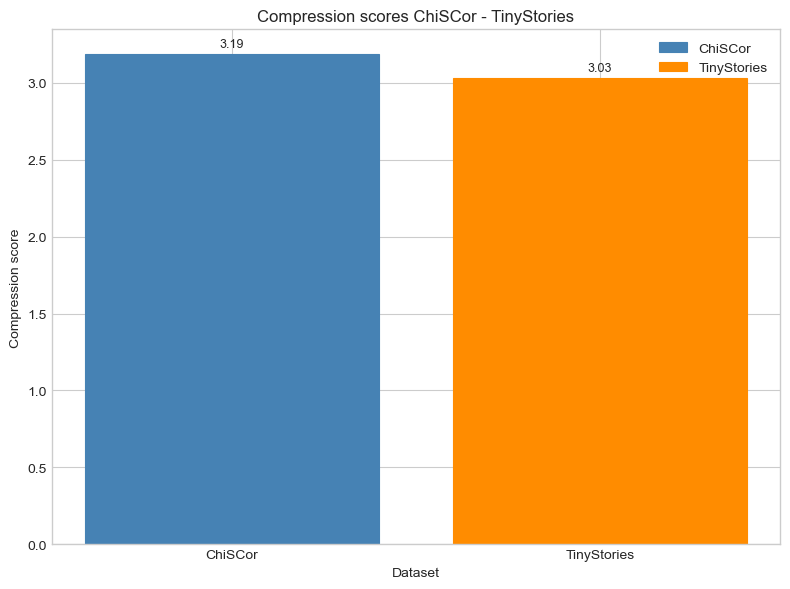

In [ ]:
plot_two_bars(cr_chiscor, cr_tinystories, label1='ChiSCor', label2='TinyStories', title='Compression scores ChiSCor - TinyStories', xlabel='Dataset', ylabel='Compression score')

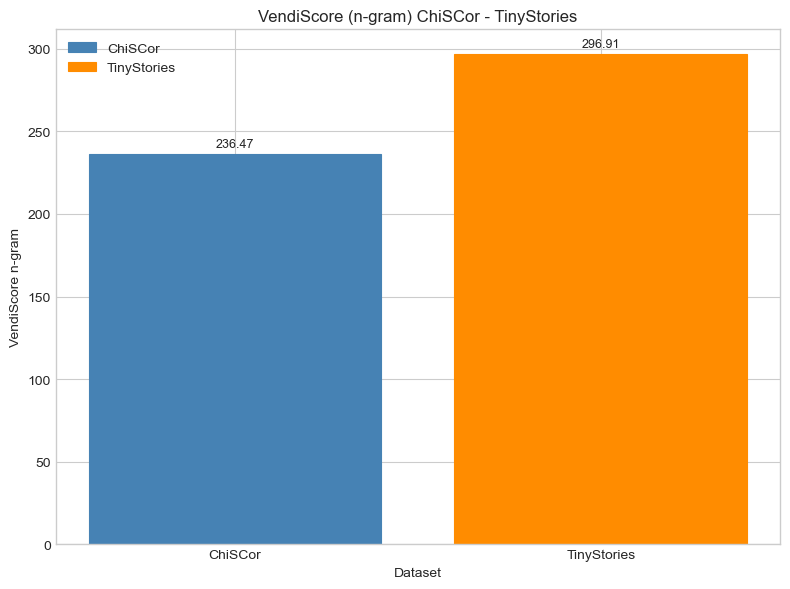

In [ ]:
plot_two_bars(ngram_vs_chiscor, ngram_vs_tiny, label1='ChiSCor', label2='TinyStories', title='VendiScore (n-gram) ChiSCor - TinyStories', xlabel='Dataset', ylabel='VendiScore n-gram')

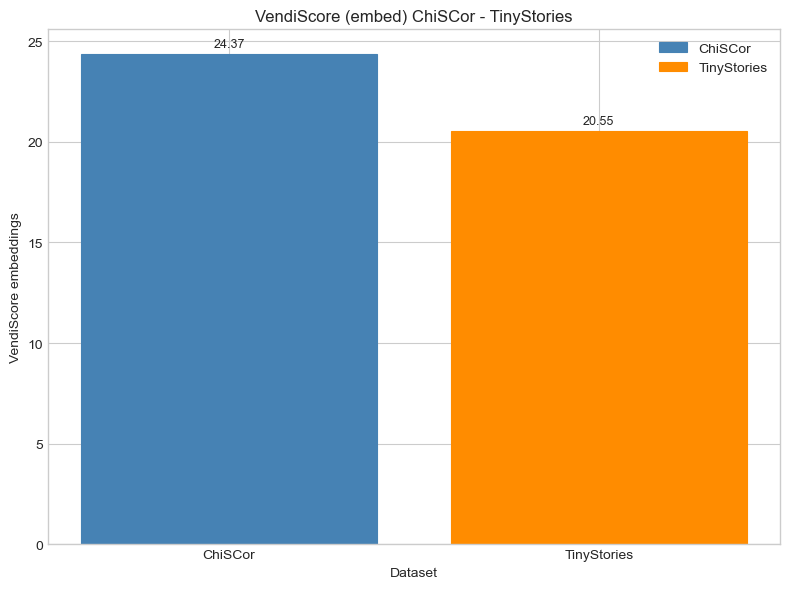

In [ ]:
plot_two_bars(embed_vs_chiscor, embed_vs_tiny, label1='ChiSCor', label2='TinyStories', title='VendiScore (embed) ChiSCor - TinyStories', xlabel='Dataset', ylabel='VendiScore embeddings')

In [ ]:
def plot_two_bars(value1,
                  value2,
                  *,
                  figure_size=(8, 6),
                  title='Dependency-constraint perplexities',
                  xlabel='Model',
                  ylabel='Value',
                  label1='TinyStories',
                  label2='TinyStories',
                  annotate=True):
    """
    Plot two bars side-by-side with the same look-and-feel as the overlapping histogram:
    - steelblue & darkorange colors
    - alpha=0.6 transparency
    - legend, title, axis labels
    """
    plt.figure(figsize=figure_size)

    # Draw the two bars (separate calls so legend picks them up cleanly)
    b1 = plt.bar(0, value1, color='steelblue', edgecolor='steelblue', linewidth=0.8, label=label1)
    b2 = plt.bar(1, value2, color='darkorange', edgecolor='darkorange', linewidth=0.8, label=label2)

    # Axes labels, ticks, title, legend
    plt.xticks([0, 1], [label1, label2])
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()

    # Optional value annotations on top of bars
    if annotate:
        for bar_container in (b1, b2):
            rect = bar_container[0]
            h = rect.get_height()
            plt.annotate(f'{h:.2f}',
                         xy=(rect.get_x() + rect.get_width() / 2, h),
                         xytext=(0, 3),
                         textcoords='offset points',
                         ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


## Plotting and analysis

In [ ]:
def plot_histogram(data, binsize=30, figure_size=(8,6), title='Dependency-constraint perplexities', xlabel='Perplexity', ylabel='Frequency'):
    plt.figure(figsize=figure_size)
    plt.hist(data, bins=binsize, edgecolor='black')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(axis='y', alpha=0.75)

In [ ]:
def plot_overlapping_hist(data1,
                          data2, 
                          *,
                          binsize=30, 
                          figure_size=(8,6), 
                          title='Dependency-constraint perplexities', 
                          xlabel='Perplexity', 
                          ylabel='Frequency',
                          label1='TinyStories',
                          label2='TinyStories'):
    data1_norm = (data1 - np.mean(data1)) / np.std(data1)
    data2_norm = (data2 - np.mean(data2)) / np.std(data2)

    plt.figure(figsize=figure_size)
    plt.hist(data1_norm, bins=binsize, color='steelblue', alpha=0.6, label=label1)
    plt.hist(data2_norm, bins=binsize, color='darkorange', alpha=0.6, label=label2)

    # Add labels and legend
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()

In [ ]:
def plot_violin_plot(data1, data2, *, xlabels=None, ylabel=None, title=None, outliers=False, showmeans=True, showmedians=True, showextrema=True):
    _, ax = plt.subplots()

    data = [data1, data2]

    cleaned = []
    labels = []
    for i, g in enumerate(data, start=1):
        g = np.asarray(g)
        g = g[np.isfinite(g)] 
        if g.size >= 2 and np.nanstd(g) > 0:
            cleaned.append(g)
            labels.append(i)              # keep index for positions
        # else: skip this group; it can’t form a violin

    axes = ax.violinplot(cleaned, showmeans=showmeans, showmedians=showmedians, showextrema=showextrema)

    axes['cmeans'].set_linestyle("-")
    axes['cmedians'].set_linestyle("--")

    # Custom legend handles
    legend_elements = [
        Line2D([0], [0], color="steelblue", lw=1, linestyle="-", label="Mean"),
        Line2D([0], [0], color="steelblue", lw=1, linestyle="--", label="Median")
    ]

    # Overlay a boxplot with fliers (outliers)
    if outliers:
        ax.boxplot(cleaned, positions=[1, 2], widths=0.1,
                showfliers=True,
                showcaps=False,
                boxprops={'color':'none'},
                whiskerprops={'linewidth':0},
                medianprops={'linewidth':0},
                flierprops=dict(marker='D', markerfacecolor='steelblue', markersize=4,
                        linestyle='none', markeredgecolor='steelblue'))
        legend_elements.append(Line2D([0], [0], marker='D', color='w', label="Outliers",
           markerfacecolor='steelblue', markeredgecolor='steelblue', markersize=4))

    ax.legend(handles=legend_elements, loc="upper right", frameon=True, fontsize=7)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(xlabels)
    ax.set_ylabel(ylabel)
    plt.title(title)

In [ ]:
df_chiscor.columns

Index(['id', 'story_lemmatized', 'story_raw', 'story_raw_no_newlines',
       'story_no', 'chardepth', 'labels', 'labels_int', 'agegroup',
       'treedepth_WNU', 'compl_avg', 'wbr_avg', 'msTTR', 'maTTR', 'MTLD',
       'MTLD_mov', 'MTLD_bi', 'HDD', 'story_PP', 'dep_dist', 'agegroup_str',
       'syntactic_depth', 'average_components', 'wbr_average',
       'lexical_diversity', 'dependency_distance', 'local_contextuality',
       'grammaticality', 'creative_perplexity_unigram',
       'creative_perplexity_bigram', 'creative_perplexity_bigram_constrained',
       'vendi_ngram', 'vendi_embeddings'],
      dtype='object')

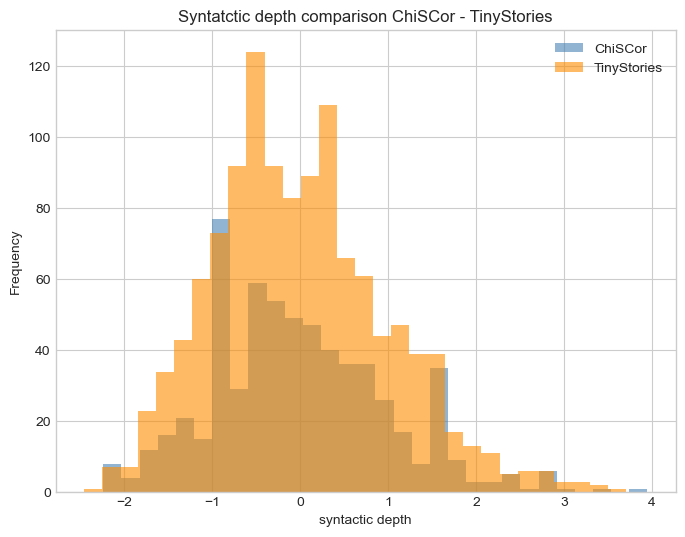

In [ ]:
plot_overlapping_hist(df_chiscor['syntactic_depth'], 
                      tinystories_dutch['syntactic_depth'],
                      title='Syntatctic depth comparison ChiSCor - TinyStories',
                      xlabel='syntactic depth',
                      label1='ChiSCor',
                      label2='TinyStories'
                      )


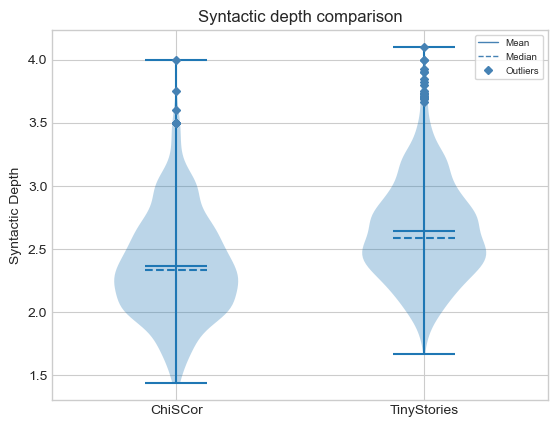

In [ ]:
plot_violin_plot(df_chiscor['syntactic_depth'], 
                 tinystories_dutch['syntactic_depth'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Syntactic Depth',
                 title="Syntactic depth comparison", 
                 outliers=True)

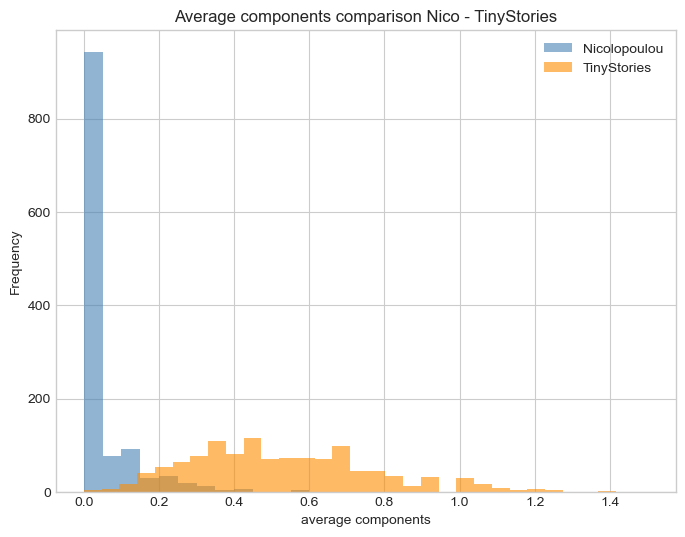

In [ ]:
plot_overlapping_hist(df_chiscor['average_components'], 
                      tinystories_dutch['average_components'],
                      title='Average components comparison ChiSCor - TinyStories',
                      xlabel='average components',
                      label1='ChiSCor',
                      label2='TinyStories'
                      )


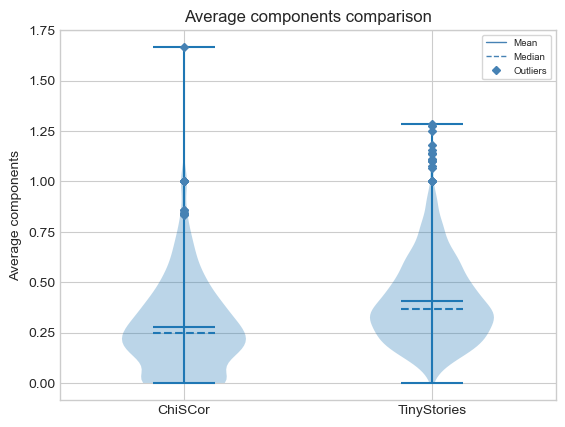

In [ ]:
plot_violin_plot(df_chiscor['average_components'], 
                 tinystories_dutch['average_components'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Average components',
                 title="Average components comparison", 
                 outliers=True)

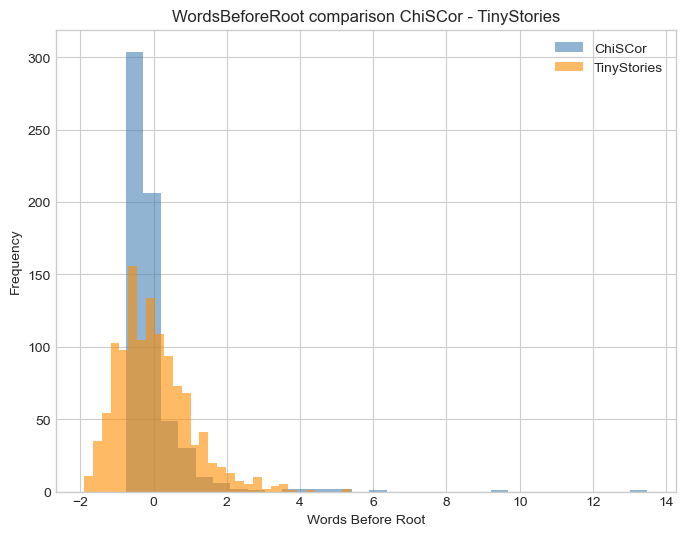

In [ ]:
plot_overlapping_hist(df_chiscor['wbr_average'], 
                      tinystories_dutch['wbr_average'],
                      title='WordsBeforeRoot comparison ChiSCor - TinyStories',
                      xlabel='Words Before Root',
                      label1='ChiSCor',
                      label2='TinyStories'
                      )

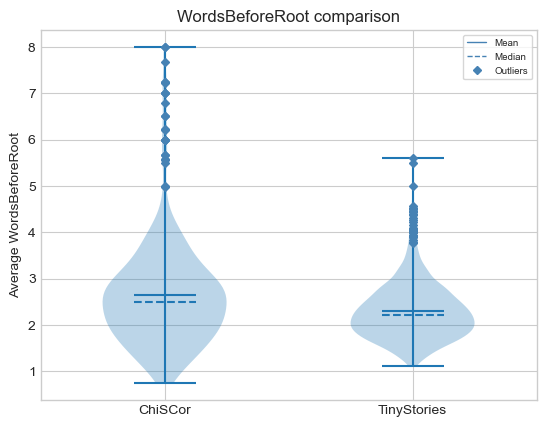

In [ ]:
plot_violin_plot(df_chiscor['wbr_average'], 
                 tinystories_dutch['wbr_average'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Average WordsBeforeRoot',
                 title="WordsBeforeRoot comparison", 
                 outliers=True)

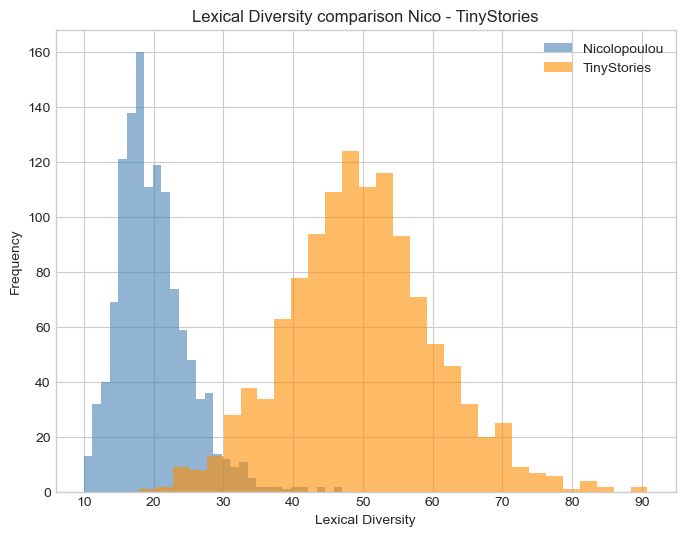

In [ ]:
plot_overlapping_hist(df_chiscor['lexical_diversity'].apply(lambda x: x.get("moving_mtld")).tolist(), 
                      tinystories_dutch['lexical_diversity'].apply(lambda x: x.get("moving_mtld")).tolist(),
                      title='Lexical Diversity comparison Nico - TinyStories',
                      xlabel='Lexical Diversity',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

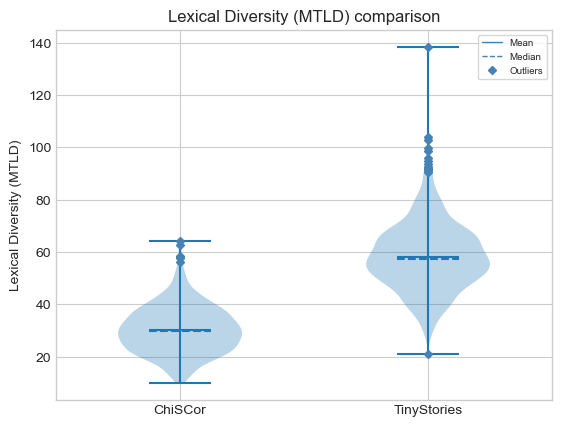

In [ ]:
plot_violin_plot(df_chiscor['lexical_diversity'].apply(lambda x: x.get("moving_mtld")).tolist(), 
                 tinystories_dutch['lexical_diversity'].apply(lambda x: x.get("moving_mtld")).tolist(), 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Lexical Diversity (MTLD)',
                 title="Lexical Diversity (MTLD) comparison", 
                 outliers=True)

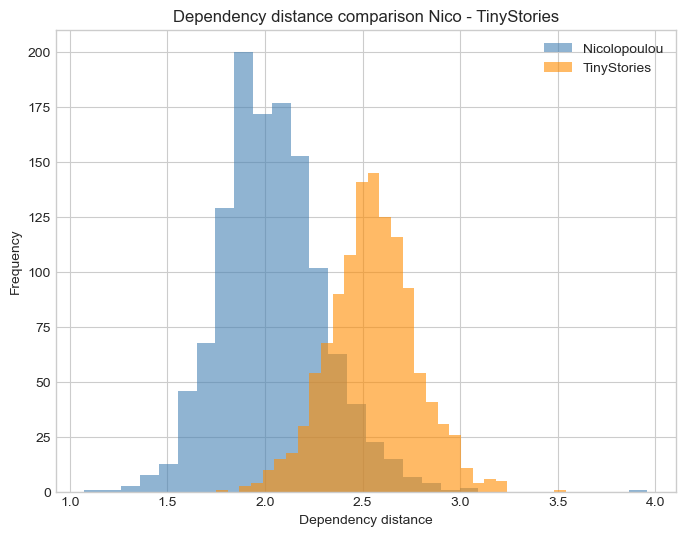

In [ ]:
plot_overlapping_hist(df_chiscor['dependency_distance'], 
                      tinystories_dutch['dependency_distance'],
                      title='Dependency distance comparison Nico - TinyStories',
                      xlabel='Dependency distance',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

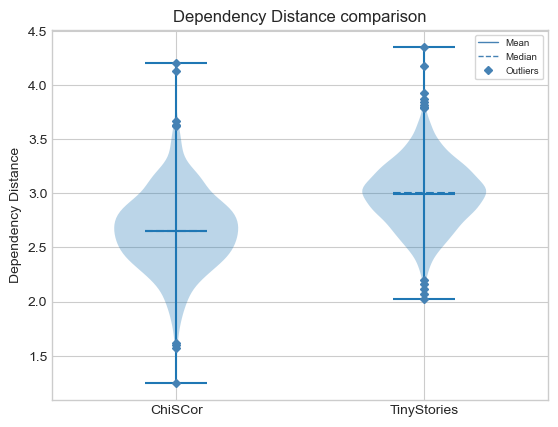

In [ ]:
plot_violin_plot(df_chiscor['dependency_distance'], 
                 tinystories_dutch['dependency_distance'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Dependency Distance',
                 title="Dependency Distance comparison", 
                 outliers=True)

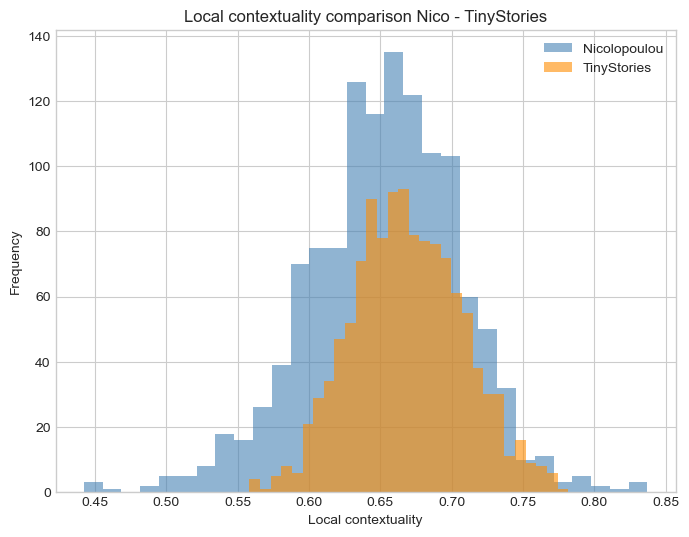

In [ ]:
plot_overlapping_hist(df_chiscor['local_contextuality'][df_chiscor['local_contextuality'] > 0.01].tolist(), # took out the 0.0 (no sentences)
                      tinystories_dutch['local_contextuality'],
                      title='Local contextuality comparison ChiSCor - TinyStories',
                      xlabel='Local contextuality',
                      label1='ChiSCor',
                      label2='TinyStories'
                      )

Info: 0.0 values are skipped. These are instances with only 1 sentence.
      Skipped 11 stories ([25, 173, 193, 340, 353, 392, 452, 478, 506, 516, 567]). 


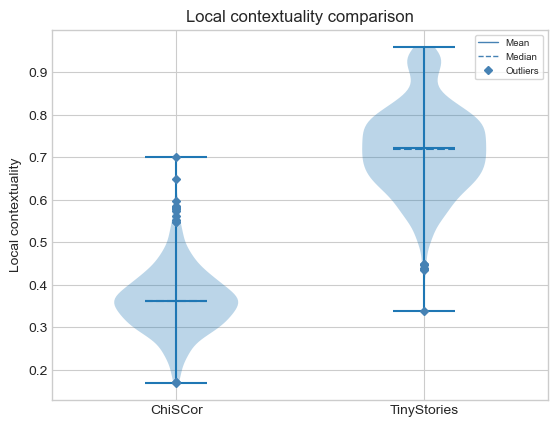

In [ ]:
zero_values = df_chiscor['local_contextuality'].isin([0.0])

print(f"""Info: 0.0 values are skipped. These are instances with only 1 sentence.
      Skipped {zero_values.sum(axis=0)} stories ({df_chiscor.index[zero_values].tolist()}). """)
plot_violin_plot(df_chiscor['local_contextuality'][df_chiscor['local_contextuality'] != 0.0], 
                 tinystories_dutch['local_contextuality'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Local contextuality',
                 title="Local contextuality comparison", 
                 outliers=True)

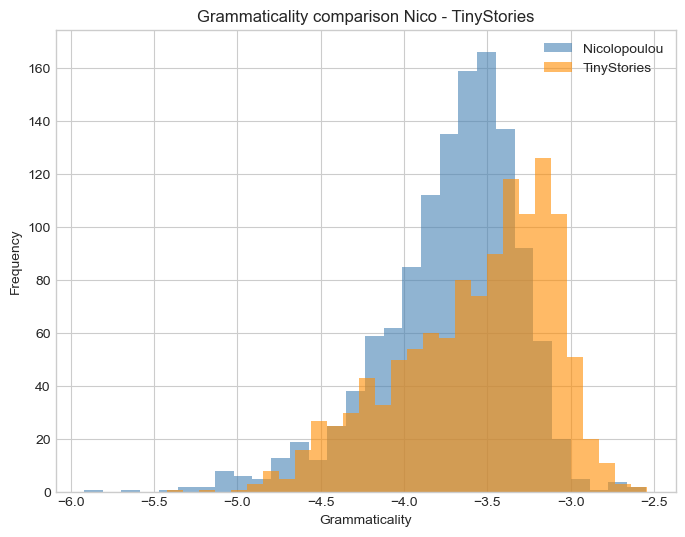

In [ ]:
plot_overlapping_hist(df_chiscor['grammaticality'], 
                      tinystories_dutch['grammaticality'],
                      title='Grammaticality comparison Nico - TinyStories',
                      xlabel='Grammaticality',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

In [ ]:
df_chiscor[df_chiscor['grammaticality'] < -2.4].sort_values(by=['grammaticality'])


,id,story_lemmatized,story_raw,story_raw_no_newlines,story_no,chardepth,labels,labels_int,agegroup,treedepth_WNU,...,dependency_distance,local_contextuality,grammaticality,creative_perplexity_unigram,creative_perplexity_bigram,creative_perplexity_bigram_constrained,vendi_ngram,vendi_embeddings,perplexity_BL,perplexity_WD
506,100901,toen ik jarig was heb ik een krijgen,toen ik jarig was heb ik een Ferrari gekregen.\n,toen ik jarig was heb ik een Ferrari gekregen.,1,1,actor,1,1,2.000000,...,2.222222,0.000000,-2.617744,292.710264,217.780365,66.510485,0.000000,0.000000,12.072299,74.604219
15,10901,mijn papa en mijn mama heten en en ik gaan al...,mijn papa en mijn mama heet en .\nen ik ga al...,mijn papa en mijn mama heet en . en ik ga alti...,1,2,actor,1,1,2.666667,...,2.047619,0.303783,-2.547951,430.468143,660.191263,202.207851,3.604130,3.289067,319.158408,146.220889
481,91701,er zijn eens een tas en die hebben been en ar...,er was eens een tas en die had benen en armen ...,er was eens een tas en die had benen en armen ...,1,8,person,3,6,2.656250,...,2.905371,0.315915,-2.534413,677.614385,282.649100,112.353762,27.744584,14.800115,167.936210,353.852209
236,41202,nou een kussen die leven en een stoel die lev...,nou een kussen die leefde en een stoel die lee...,nou een kussen die leefde en een stoel die lee...,2,4,agent,2,1,2.250000,...,3.153846,0.503539,-2.516487,557.021639,328.365277,382.338669,5.241909,4.185152,531.026598,561.241349
418,73302,er komen eens een en die zien e en toen gaan ...,er kwam eens een Power Ranger.\nen die zag een...,er kwam eens een Power Ranger. en die zag een ...,2,3,agent,2,3,1.750000,...,2.000000,0.344137,-2.495760,1856.542865,427.004765,1650.970326,3.619355,2.864758,2014.637728,176.659862
158,30303,eigenlijk naar de bioscoop en toen gaan ik ki...,eigenlijk naar de bioscoop en toen ging ik Bu...,eigenlijk naar de bioscoop en toen ging ik Buu...,3,4,agent,2,1,1.750000,...,2.456790,0.363662,-2.490552,921.128450,378.593950,73.354907,10.380640,7.332906,95.360464,173.124164
254,42501,ik heb een boek schrijven over en in en en da...,ik heb een boek geschreven over Blue Charlie D...,ik heb een boek geschreven over Blue Charlie D...,1,4,agent,2,6,2.300000,...,2.862069,0.348570,-2.481720,1856.610626,1046.389200,1966.637304,8.652381,6.675314,1401.569361,2741.438479
6,10403,toen er zijn zijn er en daarna ze moeten slap...,toen Kayo er was. \nKayo was er en daarna ze m...,toen Kayo er was. Kayo was er en daarna ze moe...,3,4,agent,2,3,2.333333,...,2.680000,0.454576,-2.458699,599.000957,681.265223,307.724154,2.968910,2.472197,18.739978,2110.453373
392,70701,wij hebben morgen ridder en prinses aan verkl...,wij hadden morgen ridders en prinsessen aan ve...,wij hadden morgen ridders en prinsessen aan ve...,1,1,actor,1,1,4.000000,...,1.875000,0.000000,-2.442717,2390.950057,627.691790,10.481073,0.000000,0.000000,18.575862,25.036136
393,70801,ik hebben twee broer en die heten en en de jo...,ik heb twee broertjes en die heten en .\nen d...,ik heb twee broertjes en die heten en . en de ...,1,2,actor,1,4,2.142857,...,2.482143,0.241374,-2.442020,844.547795,678.714406,36.676653,6.790068,5.027047,161.555226,34.574812


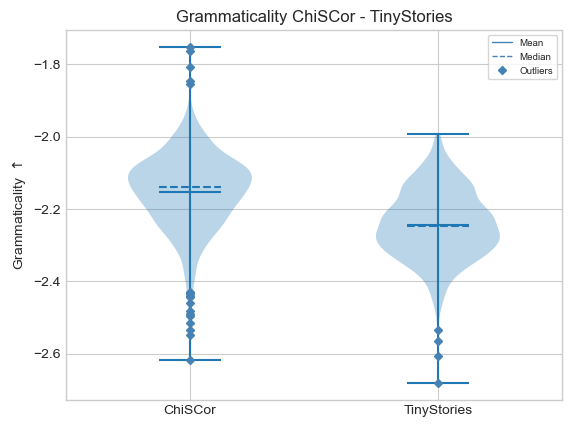

In [ ]:
plot_violin_plot(df_chiscor['grammaticality'], 
                 tinystories_dutch['grammaticality'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel=r'Grammaticality $\uparrow$',
                 title="Grammaticality ChiSCor - TinyStories", 
                 outliers=True)

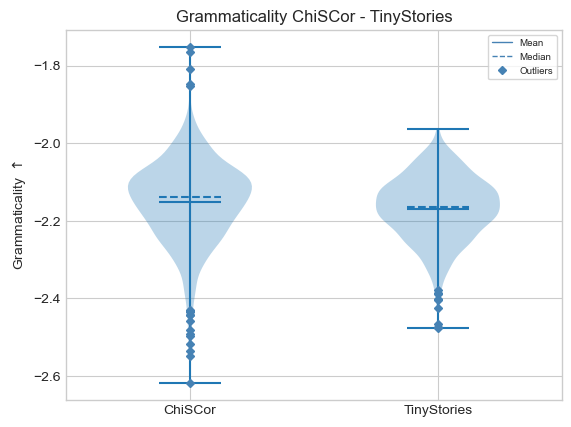

In [ ]:
plot_violin_plot(df_chiscor['grammaticality'], 
                 first_prompting['grammaticality'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel=r'Grammaticality $\uparrow$',
                 title="Grammaticality ChiSCor - TinyStories", 
                 outliers=True)

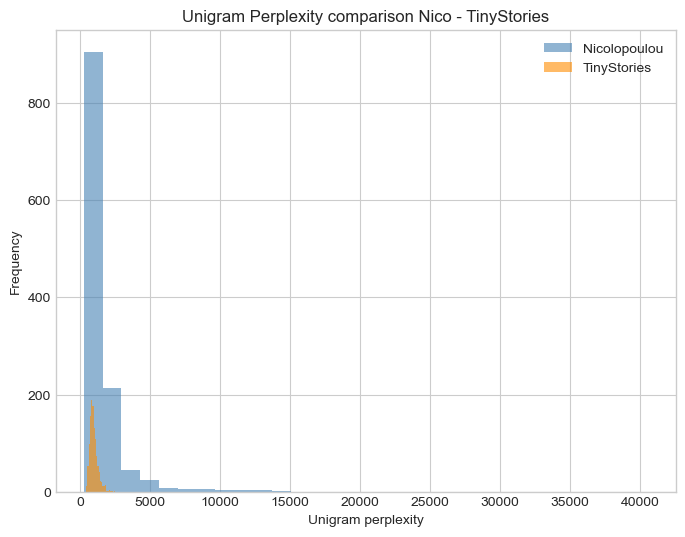

In [ ]:
plot_overlapping_hist(df_chiscor['creative_perplexity_unigram'], 
                      tinystories_dutch['creative_perplexity_unigram'],
                      title='Unigram Perplexity comparison Nico - TinyStories',
                      xlabel='Unigram perplexity',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

In [ ]:
df_chiscor['text'].iloc[1041]

'once upon a time Thomas Choo Choo Train and Henry Choo Choo Train and Asher Choo Choo Train pretend crashed. the end.'

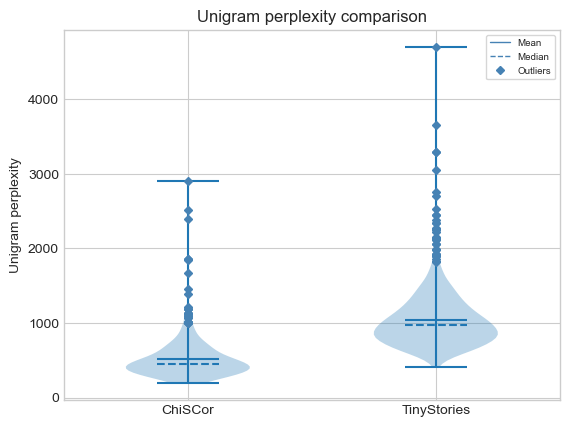

In [ ]:
plot_violin_plot(df_chiscor['creative_perplexity_unigram'], 
                 tinystories_dutch['creative_perplexity_unigram'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Unigram perplexity',
                 title="Unigram perplexity comparison", 
                 outliers=True)

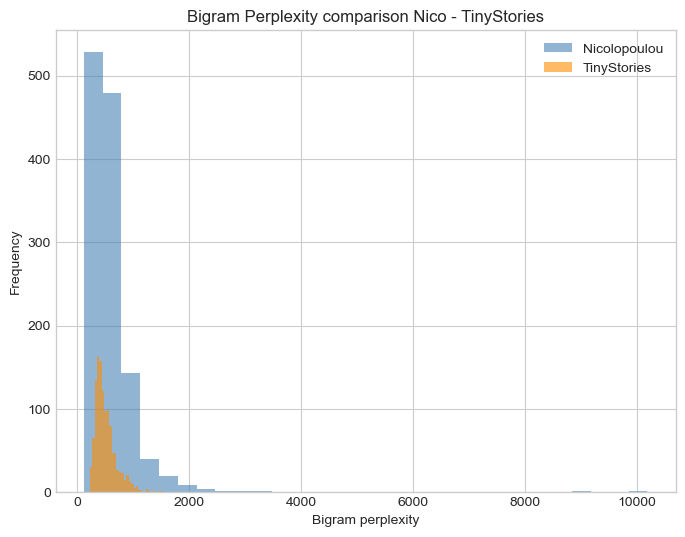

In [ ]:
plot_overlapping_hist(df_chiscor['creative_perplexity_bigram'], 
                      tinystories_dutch['creative_perplexity_bigram'],
                      title='Bigram Perplexity comparison Nico - TinyStories',
                      xlabel='Bigram perplexity',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

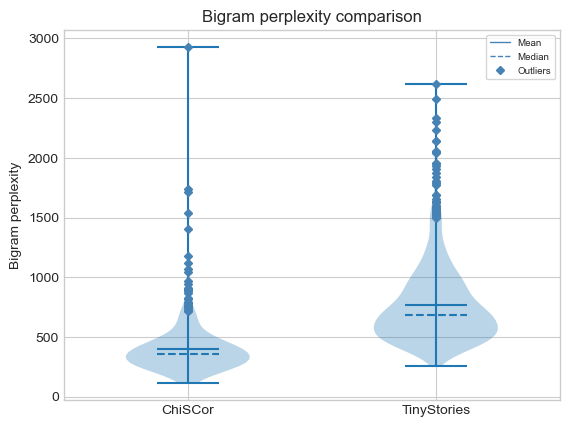

In [ ]:
plot_violin_plot(df_chiscor['creative_perplexity_bigram'], 
                 tinystories_dutch['creative_perplexity_bigram'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Bigram perplexity',
                 title="Bigram perplexity comparison", 
                 outliers=True)

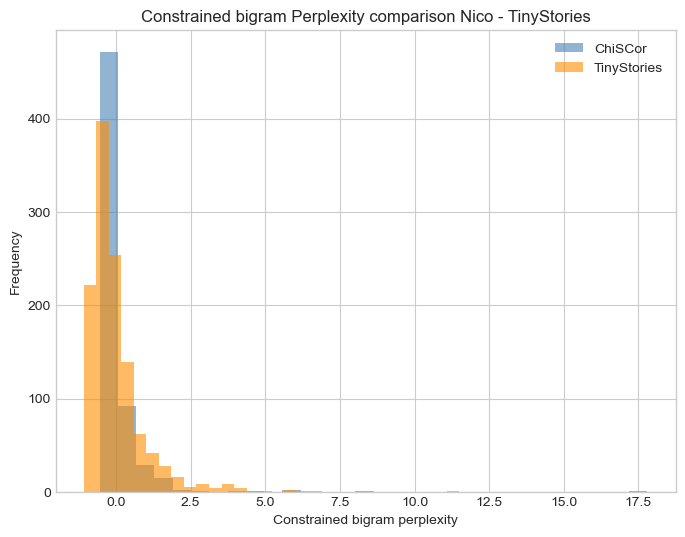

In [ ]:
plot_overlapping_hist(df_chiscor['creative_perplexity_bigram_constrained'], 
                      tinystories_dutch['creative_perplexity_bigram_constrained'],
                      title='Constrained bigram Perplexity comparison Nico - TinyStories',
                      xlabel='Constrained bigram perplexity',
                      label1='ChiSCor',
                      label2='TinyStories'
                      )

In [ ]:
outliers = df_chiscor[df_chiscor['creative_perplexity_bigram_constrained'] > 1500]

for idx, story in outliers.iterrows:
    text = story['story_raw']
    gram = story['grammaticality']
    print(text)
    print(gram)


In [ ]:
def plot_violin_plot_with_gram(
    data1, data2, *,
    xlabels=None, ylabel=None, title=None,
    outliers=False, showmeans=True, showmedians=True, showextrema=True,
    grammar1=None, grammar2=None, cmap='viridis', vmin=None, vmax=None
):
    fig, ax = plt.subplots()

    data_list = [np.asarray(data1, dtype=float), np.asarray(data2, dtype=float)]
    gram_list = []
    if grammar1 is not None or grammar2 is not None:
        gram_list = [
            None if grammar1 is None else np.asarray(grammar1, dtype=float),
            None if grammar2 is None else np.asarray(grammar2, dtype=float)
        ]
    else:
        gram_list = [None, None]

    cleaned = []
    gram_cleaned = []
    kept_idx = []

    # Clean NaNs/inf and keep groups that can form a violin
    for i, (vals, grams) in enumerate(zip(data_list, gram_list), start=1):
        mask = np.isfinite(vals)
        vals = vals[mask]
        if grams is not None:
            grams = grams[mask]
        if vals.size >= 2 and np.nanstd(vals) > 0:
            cleaned.append(vals)
            gram_cleaned.append(grams)
            kept_idx.append(i)

    if len(cleaned) == 0:
        raise ValueError("No valid data groups to plot.")

    positions = list(range(1, len(cleaned) + 1))

    vp = ax.violinplot(cleaned, positions=positions,
                       showmeans=showmeans, showmedians=showmedians, showextrema=showextrema)

    # Style mean/median lines if present
    if showmeans and 'cmeans' in vp:
        vp['cmeans'].set_linestyle("-")
    if showmedians and 'cmedians' in vp:
        vp['cmedians'].set_linestyle("--")

    # Custom legend handles for mean/median
    legend_elements = []
    if showmeans:
        legend_elements.append(Line2D([0], [0], color="steelblue", lw=1, linestyle="-", label="Mean"))
    if showmedians:
        legend_elements.append(Line2D([0], [0], color="steelblue", lw=1, linestyle="--", label="Median"))

    # Boxplot overlay (no fliers; we’ll draw them ourselves)
    if outliers:
        ax.boxplot(
            cleaned, positions=positions, widths=0.1,
            showfliers=False, showcaps=False,
            boxprops={'color': 'none'},
            whiskerprops={'linewidth': 0},
            medianprops={'linewidth': 0}
        )

        # Prepare colormap if grammaticality is provided
        have_grammar = any(g is not None for g in gram_cleaned)
        norm = None
        cmap_obj = None
        colorbar_mappable = None

        if have_grammar:
            all_scores = np.concatenate([g for g in gram_cleaned if g is not None])
            finite_scores = all_scores[np.isfinite(all_scores)]
            if finite_scores.size > 0:
                if vmin is None:
                    vmin = np.nanmin(finite_scores)
                if vmax is None:
                    vmax = np.nanmax(finite_scores)
                norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
                cmap_obj = cm.get_cmap(cmap)

        # Compute Tukey outliers and scatter them
        for pos, vals, grams in zip(positions, cleaned, gram_cleaned):
            q1 = np.percentile(vals, 25)
            q3 = np.percentile(vals, 75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            out_mask = (vals < lower) | (vals > upper)
            y_out = vals[out_mask]
            if y_out.size == 0:
                continue
            x_out = np.full_like(y_out, pos, dtype=float)

            if have_grammar and grams is not None and norm is not None and cmap_obj is not None:
                g_out = grams[out_mask]
                sc = ax.scatter(
                    x_out, y_out, marker='D', s=30,
                    c=g_out, cmap=cmap_obj, norm=norm,
                    edgecolors='black', linewidths=0.2, zorder=3
                )
                colorbar_mappable = sc  # keep last for colorbar
            else:
                ax.scatter(
                    x_out, y_out, marker='D', s=30,
                    c='steelblue', edgecolors='black', linewidths=0.2, zorder=3
                )

        # Legend + colorbar
        if have_grammar and norm is not None:
            legend_elements.append(
                Line2D([0], [0], marker='D', color='w',
                       label='Outliers (color = grammaticality)',
                       markerfacecolor='gray', markeredgecolor='black', markersize=4)
            )
            cbar = fig.colorbar(colorbar_mappable, ax=ax)
            cbar.set_label('Grammaticality')
        else:
            legend_elements.append(
                Line2D([0], [0], marker='D', color='w',
                       label="Outliers", markerfacecolor='steelblue',
                       markeredgecolor='steelblue', markersize=4)
            )

    if legend_elements:
        ax.legend(handles=legend_elements, loc="upper right", frameon=True, fontsize=7)

    # X labels (respect cleaned/kept groups)
    if xlabels is None:
        xticklabels = [f'G{i}' for i in kept_idx]
    else:
        xticklabels = [xlabels[i-1] for i in kept_idx]
    ax.set_xticks(positions)
    ax.set_xticklabels(xticklabels)

    if ylabel:
        ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    plt.tight_layout()
    return fig, ax


In [ ]:
df_chiscor['story_raw'].iloc[591]

' nou een wolf at een vogeltje op en die spuugde het uit op een klein kindje.\nen toen was het kindje dood door de wolf.\nen toen was de wolf dood door de ridder.\nen hij is afgelopen.'

In [ ]:
tinystories_dutch['creative_perplexity_bigram'].idxmax()

215

In [ ]:
tinystories_dutch['story_nl'].iloc[215]

'Lily en Ben speelden in de keuken. Ze zagen een grote pot olives op het aanrecht liggen. Lily vond olives lekker, maar Ben niet.\n\n"Kan ik een olie hebben?" vroeg Lily.\n\n"Nee, ze zijn vies," zei Ben.\n\nLily schoof haar hand in de pot en opende hem. Ze nam er een groene olijf uit en stopte hem in haar mond. Ze glimlachte.\n\n"Mmm, ze zijn lekker," zei ze.\n\nBen trok een grimas. Hij wilde geen olijf proberen. Hij zag een stomme mes op het snijplank liggen. Hij pakte het op en imiteerde een keukenhulp.\n\n"Kijk, ik ben een chef!" zei hij.\n\nHij sneed een olijf doormidden en drukte hem. Het sap spetterde uit en raakte zijn oog.\n\n"Oh, oh, oh!", riep hij.\n\nLily liet zakken en rende naar hem toe. Ze zag dat zijn oog rood en vochtig was.\n\n"Hoef je het goed?", vroeg ze.\n\nBen veegde zijn oog en snoof.\n\n"Dat doet pijn," zei hij.\n\nLily omhelsde hem en zei, "Sorry. Laat me even een handdoek halen."\n\nZe rende naar het aanrecht en pakte een handdoek. Ze kwam terug en wreef voorzi

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_72445/2106176293.py:85: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = cm.get_cmap(cmap)


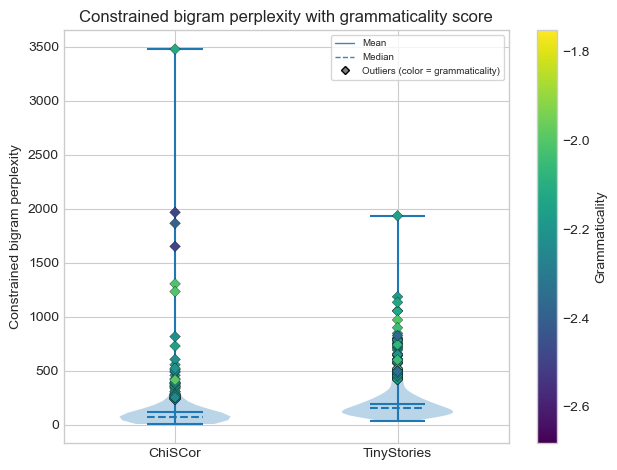

In [ ]:
fig, ax = plot_violin_plot_with_gram(
    df_chiscor['creative_perplexity_bigram_constrained'], tinystories_dutch['creative_perplexity_bigram_constrained'],
    xlabels=["ChiSCor", "TinyStories"],
    ylabel="Constrained bigram perplexity",
    title="Constrained bigram perplexity with grammaticality score",
    outliers=True,
    grammar1=df_chiscor['grammaticality'],
    grammar2=tinystories_dutch['grammaticality'],
    cmap='viridis'                    # any Matplotlib cmap
)

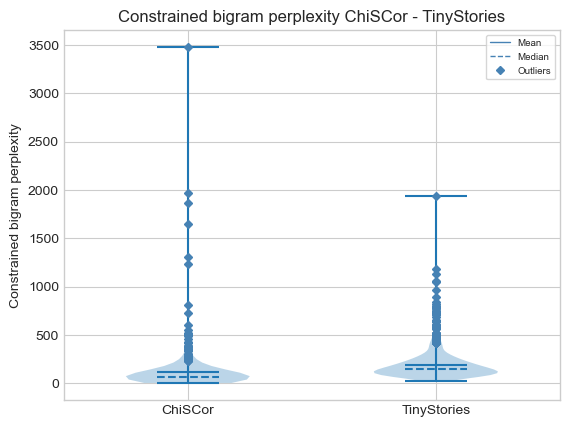

In [ ]:
plot_violin_plot(df_chiscor['creative_perplexity_bigram_constrained'], 
                 tinystories_dutch['creative_perplexity_bigram_constrained'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Constrained bigram perplexity',
                 title='Constrained bigram perplexity ChiSCor - TinyStories', 
                 outliers=True)

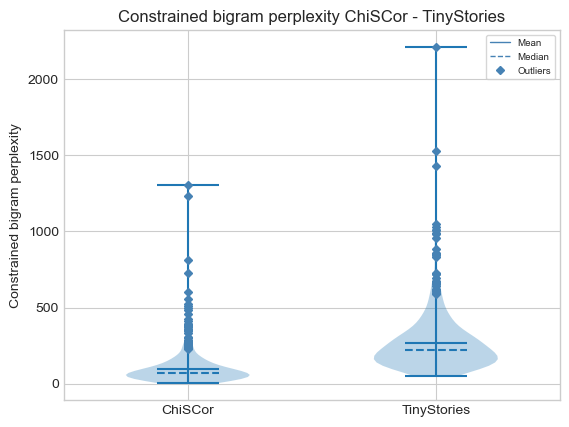

In [ ]:
plot_violin_plot(df_chiscor['creative_perplexity_bigram_constrained'][df_chiscor['creative_perplexity_bigram_constrained'] < 1500].tolist(), 
                 first_prompting['creative_perplexity_bigram_constrained'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Constrained bigram perplexity',
                 title='Constrained bigram perplexity ChiSCor - TinyStories', 
                 outliers=True)

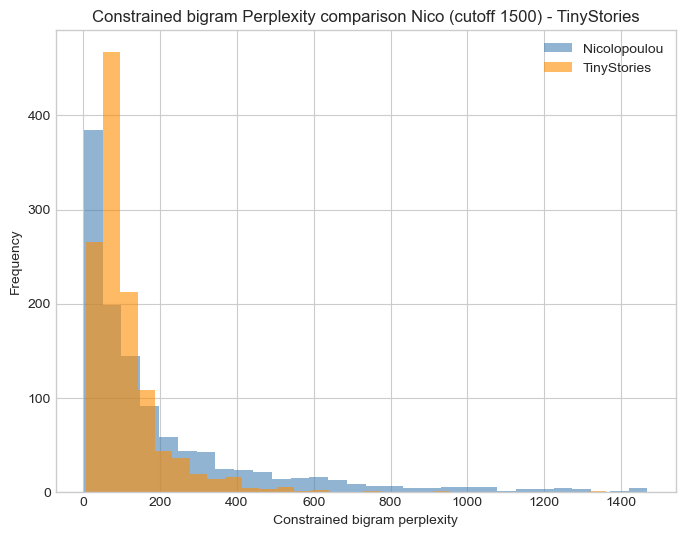

In [ ]:
plot_overlapping_hist(df_chiscor['creative_perplexity_bigram_constrained'][df_chiscor['creative_perplexity_bigram_constrained'] < 1500].tolist(), 
                      tinystories_dutch['creative_perplexity_bigram_constrained'],
                      title='Constrained bigram Perplexity comparison Nico (cutoff 1500) - TinyStories',
                      xlabel='Constrained bigram perplexity',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

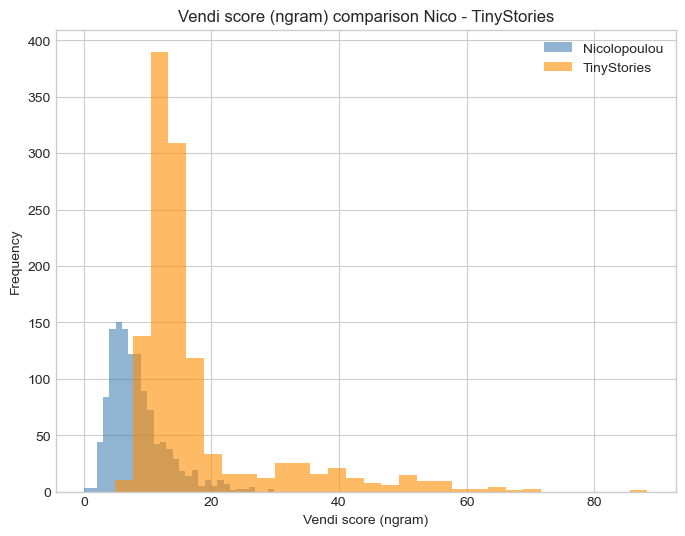

In [ ]:
plot_overlapping_hist(df_chiscor['vendi_ngram'], 
                      tinystories_dutch['vendi_ngram'],
                      title='Vendi score (ngram) comparison Nico - TinyStories',
                      xlabel='Vendi score (ngram)',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

In [ ]:
df_chiscor['vendi_ngram'][df_chiscor['vendi_ngram'] < 200]

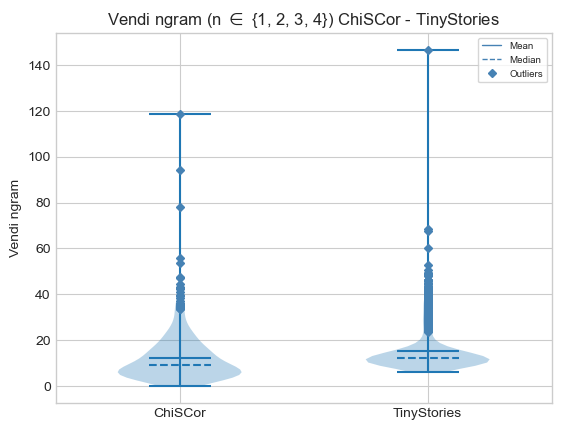

In [ ]:
plot_violin_plot(df_chiscor['vendi_ngram'][df_chiscor['vendi_ngram'] < 200], 
                 tinystories_dutch['vendi_ngram'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Vendi ngram',
                 title=r'Vendi ngram (n $\in$ {1, 2, 3, 4}) ChiSCor - TinyStories', 
                 outliers=True)

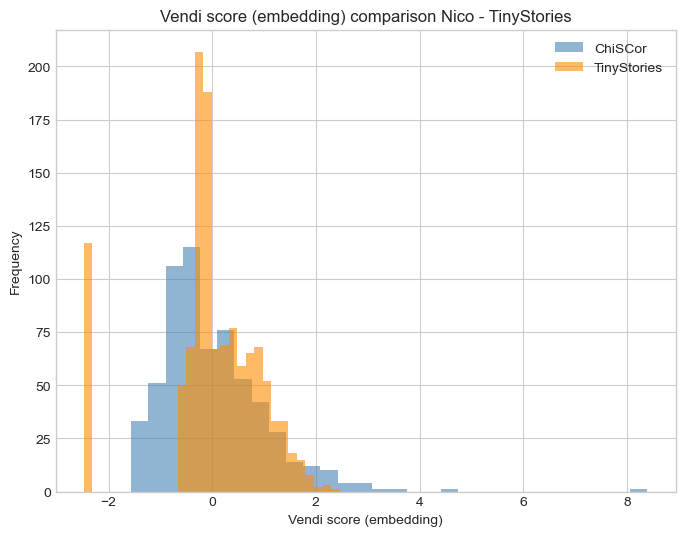

In [ ]:
plot_overlapping_hist(df_chiscor['vendi_embeddings'], 
                      tinystories_dutch['vendi_embeddings'],
                      title='Vendi score (embedding) comparison Nico - TinyStories',
                      xlabel='Vendi score (embedding)',
                      label1='ChiSCor',
                      label2='TinyStories'
                      )

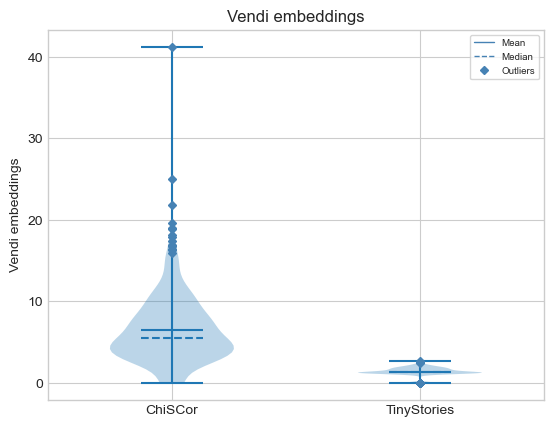

In [ ]:
plot_violin_plot(df_chiscor['vendi_embeddings'], 
                tinystories_dutch['vendi_embeddings'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Vendi embeddings',
                 title='Vendi embeddings', 
                 outliers=True)

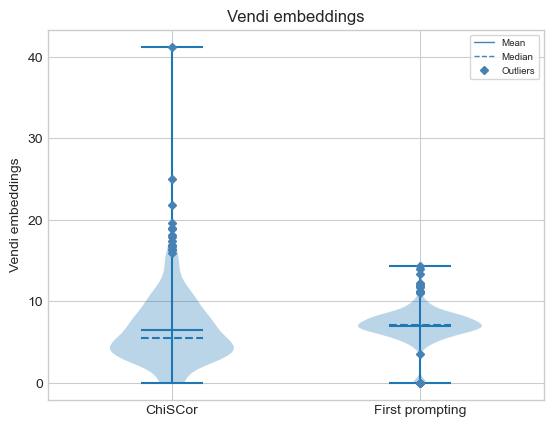

In [ ]:
plot_violin_plot(df_chiscor['vendi_embeddings'], 
                first_prompting['vendi_embeddings'], 
                 xlabels=['ChiSCor', 'First prompting'], 
                 ylabel='Vendi embeddings',
                 title='Vendi embeddings', 
                 outliers=True)

In [ ]:
def vendi_test(text: str):
    text = text.replace('\n', '')
    sents = list(map(str, list(nlp(text).sents)))

    if len(sents) < 2:
        return 0.0

    try:
        return float(
                text_utils.embedding_vendi_score(sents, model_path='jegormeister/bert-base-dutch-cased')
            )
    except Exception:
        return 0.0

### ChiSCor like vendi V2

In [ ]:
chiscor_like_v2 = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/results/prompt_ChiSCor_like_V2.csv')

In [ ]:
chiscor_like_v2['vendi_embedding'] = chiscor_like_v2.apply(lambda row: vendi_test(row['completion']), axis = 1)

In [ ]:
embed_vs_chiscor_syn_V2 = text_utils.embedding_vendi_score(list(map(str, chiscor_like_v2['completion'].to_list())), model_path='jegormeister/bert-base-dutch-cased')

In [ ]:
embed_vs_chiscor_syn_V2

10.879343

In [ ]:
cr_syn_chiscor_V2 = compression_ratio(chiscor_like_v2['completion'].to_list(), algorithm='gzip')
print(f"Compression Ratio chiscor: {cr_syn_chiscor_V2:.4f}")

Compression Ratio chiscor: 2.9790


### ChiSCor like V1 vendi

In [ ]:
chiscor_like['vendi_embedding'] = chiscor_like.apply(lambda row: vendi_test(row['completion']), axis = 1)

In [ ]:
text_utils.embedding_vendi_score(test_story, model_path='jegormeister/bert-base-dutch-cased')

13.023405

In [ ]:
chiscor_like['completion'].iloc[0]

'Er was eens een klein dorpje, verscholen tussen de hoge bomen van een dicht bos. In dit dorpje woonde eenagate houthakker genaamd Hans. Hij was een van de sterkste mannen in het dorp en het liefst hakte hij de hele dag bomen om om geld te verdienen.\n\nOp een dag kreeg Hans een speciale opdracht. De burgemeester van het dorp vroeg hem om een enorm houten standbeeld te maken van een draak. Het standbeeld moest in het midden van het dorp gezet worden en Hans zou er veel geld voor krijgen.\n\nHans ging meteen aan het werk. Hij hakte een reusachtige boom om en begon het hout te snijden in de vorm van een prachtige draak. Het duurde een paar dagen, maar toen was het eindelijk klaar.\n\nDe burgemeester was sangat tevreden en vroeg Hans om het standbeeld te gaan verven. Hans koos voor een helderrode kleur en begon te schilderen. Toen hij klaar was, stond er een geweldig standbeeld in het midden van het dorp.\n\nMaar op de avond van de onthulling gebeurde er iets vreemds. Het standbeeld begon

In [ ]:
embed_vs_chiscor_syn = text_utils.embedding_vendi_score(list(map(str, chiscor_like['completion'].to_list())), model_path='jegormeister/bert-base-dutch-cased')
embed_vs_chiscor_syn

In [ ]:
cr_syn_chiscor = compression_ratio(synthetic_chiscor['completion'].to_list(), algorithm='gzip')
print(f"Compression Ratio chiscor: {cr_syn_chiscor:.4f}")

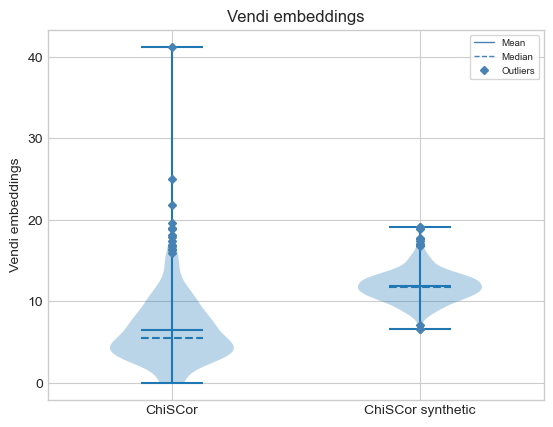

In [ ]:
plot_violin_plot(df_chiscor['vendi_embeddings'], 
                chiscor_like_v2['vendi_embedding'][chiscor_like_v2['vendi_embedding'] > 0.0], 
                 xlabels=['ChiSCor', 'ChiSCor synthetic'], 
                 ylabel='Vendi embeddings',
                 title='Vendi embeddings', 
                 outliers=True)

In [ ]:
def plot_three_violins(data1, data2, data3, *, xlabels=None, ylabel=None, title=None, outliers=False, showmeans=True, showmedians=True, showextrema=True):
    _, ax = plt.subplots()

    data = [data1, data2, data3]

    cleaned = []
    labels = []
    for i, g in enumerate(data, start=1):
        g = np.asarray(g)
        g = g[np.isfinite(g)] 
        if g.size >= 2 and np.nanstd(g) > 0:
            cleaned.append(g)
            labels.append(i)              # keep index for positions
        # else: skip this group; it can’t form a violin

    axes = ax.violinplot(cleaned, showmeans=showmeans, showmedians=showmedians, showextrema=showextrema)

    axes['cmeans'].set_linestyle("-")
    axes['cmedians'].set_linestyle("--")

    # Custom legend handles
    legend_elements = [
        Line2D([0], [0], color="steelblue", lw=1, linestyle="-", label="Mean"),
        Line2D([0], [0], color="steelblue", lw=1, linestyle="--", label="Median")
    ]

    # Overlay a boxplot with fliers (outliers)
    if outliers:
        ax.boxplot(cleaned, positions=[1, 2, 3], widths=0.1,
                showfliers=True,
                showcaps=False,
                boxprops={'color':'none'},
                whiskerprops={'linewidth':0},
                medianprops={'linewidth':0},
                flierprops=dict(marker='D', markerfacecolor='steelblue', markersize=4,
                        linestyle='none', markeredgecolor='steelblue'))
        legend_elements.append(Line2D([0], [0], marker='D', color='w', label="Outliers",
           markerfacecolor='steelblue', markeredgecolor='steelblue', markersize=4))

    ax.legend(handles=legend_elements, loc="upper right", frameon=True, fontsize=7)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(xlabels)
    ax.set_ylabel(ylabel)
    plt.title(title)

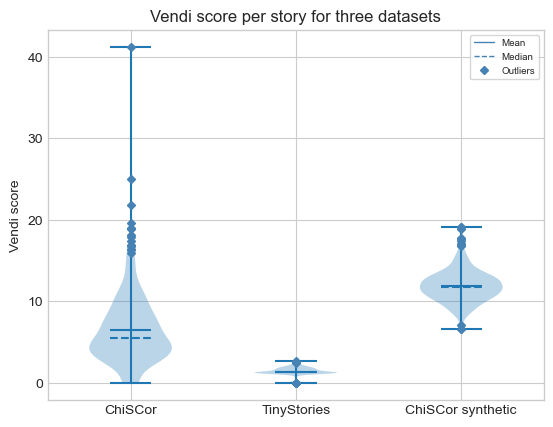

In [ ]:
plot_three_violins(df_chiscor['vendi_embeddings'], 
                   tinystories_dutch['vendi_embeddings'],
                chiscor_like_v2['vendi_embedding'][chiscor_like_v2['vendi_embedding'] > 0.0], 
                 xlabels=['ChiSCor', 'TinyStories', 'ChiSCor synthetic'], 
                 ylabel='Vendi score',
                 title='Vendi score per story for three datasets', 
                 outliers=True)

## Different reference corpora

In [ ]:
BL_standard_dep = Path('datasets/BasiLex/BL_dep_lexicon.csv')

eval_f_consumpation_ref = EvaluationFramework(language='nl',
                              pos_unigram=ref_spoken_u_csv, 
                              pos_bigram=ref_spoken_b_csv,
                              pos_trigram=ref_spoken_t_csv,
                              ref_unigram=ref_standard_uni,
                              ref_bigram=ref_standard_bi,
                              ref_ling_constrained=BL_standard_dep,
                              embedding_model='jegormeister/bert-base-dutch-cased')

In [ ]:
WD_standard_dep = Path('datasets/WikiDutch/WD_dep_lexicon.csv')

eval_f_WD_ref = EvaluationFramework(language='nl',
                              pos_unigram=ref_spoken_u_csv, 
                              pos_bigram=ref_spoken_b_csv,
                              pos_trigram=ref_spoken_t_csv,
                              ref_unigram=ref_standard_uni,
                              ref_bigram=ref_standard_bi,
                              ref_ling_constrained=WD_standard_dep,
                              embedding_model='jegormeister/bert-base-dutch-cased')

In [ ]:
eval_f_consumpation_ref.add_pipe('creative_perplexity_bigram_constrained')
eval_f_WD_ref.add_pipe('creative_perplexity_bigram_constrained')

In [ ]:
df_chiscor['perplexity_BL'] = df_chiscor.apply(lambda row: eval_f_consumpation_ref.run_component('creative_perplexity_bigram_constrained', row['story_raw_no_newlines']), axis = 1) 
tinystories_dutch['perplexity_BL'] = tinystories_dutch.apply(lambda row: eval_f_consumpation_ref.run_component('creative_perplexity_bigram_constrained', row['story_nl']), axis = 1) 

In [ ]:
df_chiscor['perplexity_WD'] = df_chiscor.apply(lambda row: eval_f_WD_ref.run_component('creative_perplexity_bigram_constrained', row['story_raw_no_newlines']), axis = 1) 
tinystories_dutch['perplexity_WD'] = tinystories_dutch.apply(lambda row: eval_f_WD_ref.run_component('creative_perplexity_bigram_constrained', row['story_nl']), axis = 1) 

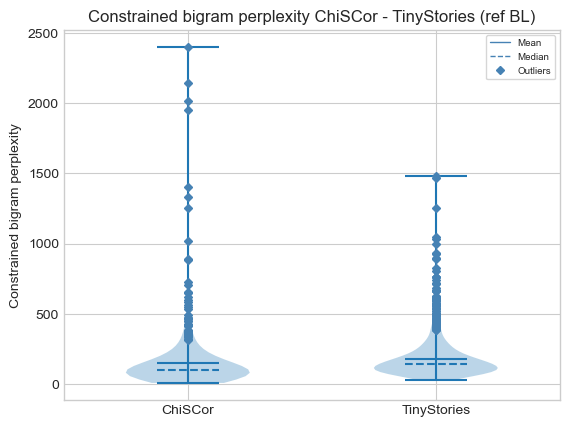

In [ ]:
plot_violin_plot(df_chiscor['perplexity_BL'], 
                 tinystories_dutch['perplexity_BL'],
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Constrained bigram perplexity',
                 title='Constrained bigram perplexity ChiSCor - TinyStories (ref BL)', 
                 outliers=True)

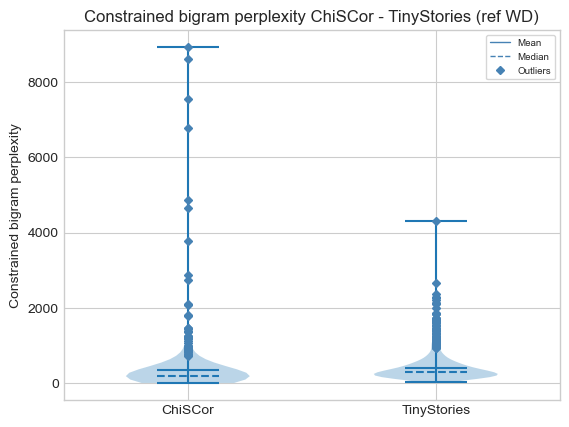

In [ ]:
plot_violin_plot(df_chiscor['perplexity_WD'][df_chiscor['perplexity_WD'] < 10_000], 
                 tinystories_dutch['perplexity_WD'],
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Constrained bigram perplexity',
                 title='Constrained bigram perplexity ChiSCor - TinyStories (ref WD)', 
                 outliers=True)

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_72445/2106176293.py:85: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = cm.get_cmap(cmap)


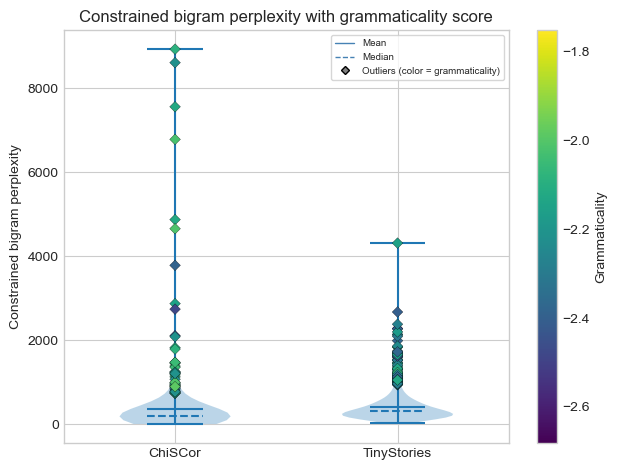

In [ ]:
fig, ax = plot_violin_plot_with_gram(
    df_chiscor['perplexity_WD'][df_chiscor['perplexity_WD'] < 10_000], tinystories_dutch['perplexity_WD'],
    xlabels=["ChiSCor", "TinyStories"],
    ylabel="Constrained bigram perplexity",
    title="Constrained bigram perplexity with grammaticality score",
    outliers=True,
    grammar1=df_chiscor['grammaticality'][df_chiscor['perplexity_WD'] < 10_000],
    grammar2=tinystories_dutch['grammaticality'],
    cmap='viridis'                    # any Matplotlib cmap
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def plot_violin_plot4(
    data1, data2, data3, data4, *,
    xlabels=None,
    ylabel=None,
    title=None,
    outliers=False,
    showmeans=True,
    showmedians=True,
    showextrema=True,
    left_color="steelblue",
    right_color="tomato",
    alpha=0.6
):
    _, ax = plt.subplots()

    data = [data1, data2, data3, data4]

    # Clean and keep only plottable groups
    cleaned = []
    for g in data:
        g = np.asarray(g)
        g = g[np.isfinite(g)]
        if g.size >= 2 and np.nanstd(g) > 0:
            cleaned.append(g)

    if len(cleaned) == 0:
        raise ValueError("None of the provided datasets can form a violin (need at least 2 finite, non-constant values).")

    positions = list(range(1, len(cleaned) + 1))

    # Violin plot
    axes = ax.violinplot(
        cleaned,
        positions=positions,
        showmeans=showmeans,
        showmedians=showmedians,
        showextrema=showextrema
    )

    # Colors per group (first two = left, rest = right)
    colors_per_group = []
    for i, body in enumerate(axes["bodies"]):
        col = left_color if i < 2 else right_color
        colors_per_group.append(col)
        body.set_facecolor(col)
        body.set_edgecolor(col)
        body.set_alpha(alpha)

    # Style and COLOR central lines (means/medians) per group
    if showmeans and "cmeans" in axes:
        axes["cmeans"].set_linestyle("-")
        try:
            axes["cmeans"].set_color(colors_per_group)  # LineCollection: one color per segment
        except Exception:
            axes["cmeans"].set_color(left_color)  # fallback
    if showmedians and "cmedians" in axes:
        axes["cmedians"].set_linestyle("--")
        try:
            axes["cmedians"].set_color(colors_per_group)
        except Exception:
            axes["cmedians"].set_color(right_color)  # fallback

    # Color extrema (cbars/cmins/cmaxes) per group with full opacity
    if showextrema:
        for key in ("cbars", "cmins", "cmaxes"):
            if key in axes:
                try:
                    axes[key].set_color(colors_per_group)
                except Exception:
                    axes[key].set_color(left_color)

    # Optional boxplot overlay JUST for fliers, colored per side
    if outliers:
        left_idx  = [i for i in range(min(2, len(cleaned)))]
        right_idx = [i for i in range(2, len(cleaned))]

        if left_idx:
            ax.boxplot(
                [cleaned[i] for i in left_idx],
                positions=[positions[i] for i in left_idx],
                widths=0.1,
                showfliers=True,
                showcaps=False,
                boxprops={'color': 'none'},
                whiskerprops={'linewidth': 0},
                medianprops={'linewidth': 0},
                flierprops=dict(
                    marker='D',
                    markerfacecolor=left_color,
                    markersize=4,
                    linestyle='none',
                    markeredgecolor=left_color
                )
            )
        if right_idx:
            ax.boxplot(
                [cleaned[i] for i in right_idx],
                positions=[positions[i] for i in right_idx],
                widths=0.1,
                showfliers=True,
                showcaps=False,
                boxprops={'color': 'none'},
                whiskerprops={'linewidth': 0},
                medianprops={'linewidth': 0},
                flierprops=dict(
                    marker='D',
                    markerfacecolor=right_color,
                    markersize=4,
                    linestyle='none',
                    markeredgecolor=right_color
                )
            )

    # Legend: show line styles + color groups
    legend_elements = [
        Line2D([0], [0], color=left_color,  lw=1, linestyle="-",  label="Mean (left)"),
        Line2D([0], [0], color=right_color, lw=1, linestyle="-",  label="Mean (right)"),
        Line2D([0], [0], color=left_color,  lw=1, linestyle="--", label="Median (left)"),
        Line2D([0], [0], color=right_color, lw=1, linestyle="--", label="Median (right)"),
        Patch(facecolor=left_color,  edgecolor=left_color,  label="Left violins (1–2)"),
        Patch(facecolor=right_color, edgecolor=right_color, label="Right violins (3–4)")
    ]
    if outliers:
        legend_elements += [
            Line2D([0], [0], marker='D', color='w', label="Outliers (left)",
                   markerfacecolor=left_color, markeredgecolor=left_color, markersize=5),
            Line2D([0], [0], marker='D', color='w', label="Outliers (right)",
                   markerfacecolor=right_color, markeredgecolor=right_color, markersize=5),
        ]
    ax.legend(handles=legend_elements, loc="upper right", frameon=True, fontsize=7)

    # X ticks & labels
    ax.set_xticks(positions)
    if xlabels is None:
        xlabels = [f"Group {i}" for i in positions]
    else:
        xlabels = xlabels[:len(positions)]
    ax.set_xticklabels(xlabels)

    # Labels & title
    if ylabel:
        ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    plt.tight_layout()
    return ax


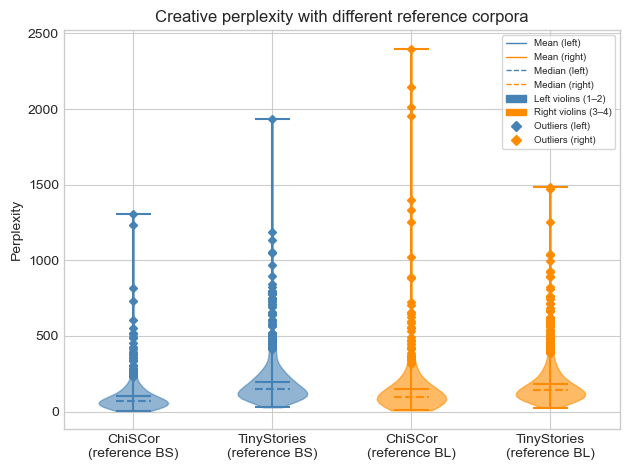

In [ ]:
ax = plot_violin_plot4(
    df_chiscor['creative_perplexity_bigram_constrained'][df_chiscor['creative_perplexity_bigram_constrained'] < 1500].tolist(), 
    tinystories_dutch['creative_perplexity_bigram_constrained'], 
    df_chiscor['perplexity_BL'], 
    tinystories_dutch['perplexity_BL'],
    xlabels=["ChiSCor\n(reference BS)","TinyStories\n(reference BS)","ChiSCor\n(reference BL)","TinyStories\n(reference BL)"],
    ylabel="Perplexity",
    title="Creative perplexity with different reference corpora",
    outliers=True,
    left_color="steelblue",
    right_color="darkorange"
)


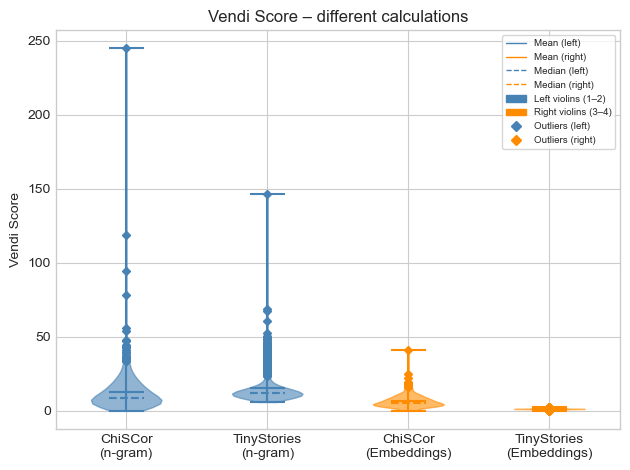

In [ ]:
ax = plot_violin_plot4(
    df_chiscor['vendi_ngram'], 
    tinystories_dutch['vendi_ngram'], 
    df_chiscor['vendi_embeddings'], 
    tinystories_dutch['vendi_embeddings'],
    xlabels=["ChiSCor\n(n-gram)","TinyStories\n(n-gram)","ChiSCor\n(Embeddings)","TinyStories\n(Embeddings)"],
    ylabel="Vendi Score",
    title="Vendi Score – different calculations",
    outliers=True,
    left_color="steelblue",
    right_color="darkorange"
)

## Analysis dependency distances ages in prompting

In [25]:
age_llama['DD'] = age_llama.apply(lambda row: eval_f.run_component('dependency_distance', row['story']), axis = 1) 
age_gemma['DD'] = age_gemma.apply(lambda row: eval_f.run_component('dependency_distance', row['story']), axis = 1)

In [40]:
age_improved_llama['DD'] = age_improved_llama.apply(lambda row: eval_f.run_component('dependency_distance', row['story']), axis = 1) 
age_improved_gemma['DD'] = age_improved_gemma.apply(lambda row: eval_f.run_component('dependency_distance', row['story']), axis = 1)

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_25867/724049714.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(50, len(x)), random_state=42))


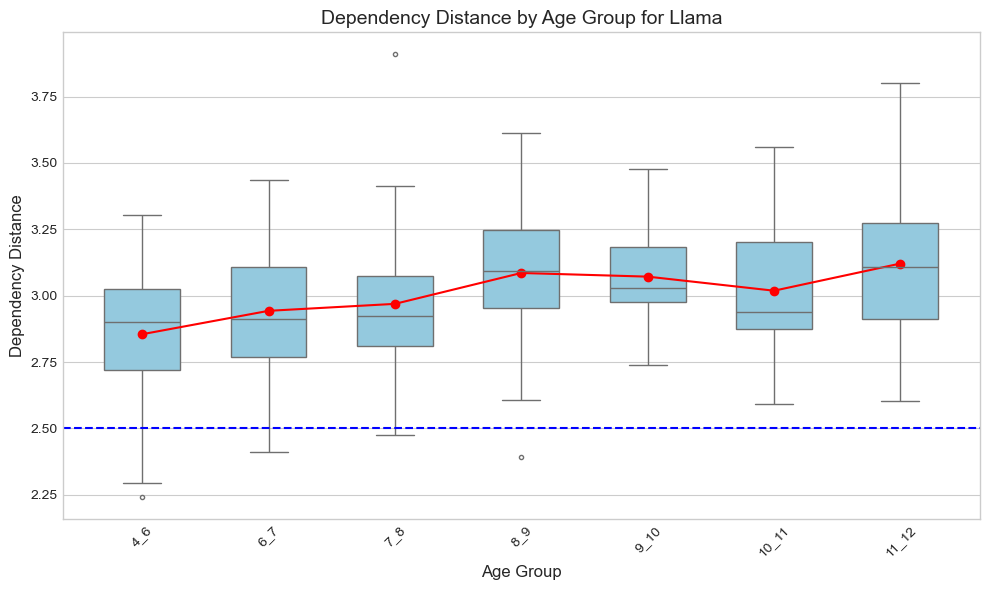

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Sample max 50 per age group
df_sampled = (
    age_llama.groupby("age", group_keys=False)
      .apply(lambda x: x.sample(n=min(50, len(x)), random_state=42))
)

# 2. Sort age groups numerically by their lower bound
# Extract the lower bound as an integer
age_order = (
    df_sampled["age"]
    .unique()
)
age_order = sorted(age_order, key=lambda x: int(x.split("_")[0]))

# 3. Create box plot with sorted x-axis
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_sampled[['age', 'DD']],
    x="age",
    y="DD",
    order=age_order,   # sorted order here
    color="skyblue",
    fliersize=3,
    width=0.6
)

# 5. Add trend line (mean per age group)
# 3. Compute mean dependency distance per age group (for trend line)
mean_values = (
    df_sampled.groupby("age")["DD"]
    .mean()
    .reindex(age_order)
)
plt.plot(age_order, mean_values, color="red", marker="o", linestyle="-", label="Mean trend")

# 6. Add horizontal reference line at y=2.5
plt.axhline(y=2.5, color="blue", linestyle="--", linewidth=1.5, label="y = 2.5")


# 4. Aesthetics
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Dependency Distance", fontsize=12)
plt.title("Dependency Distance by Age Group for Llama", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_25867/104646545.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(50, len(x)), random_state=42))


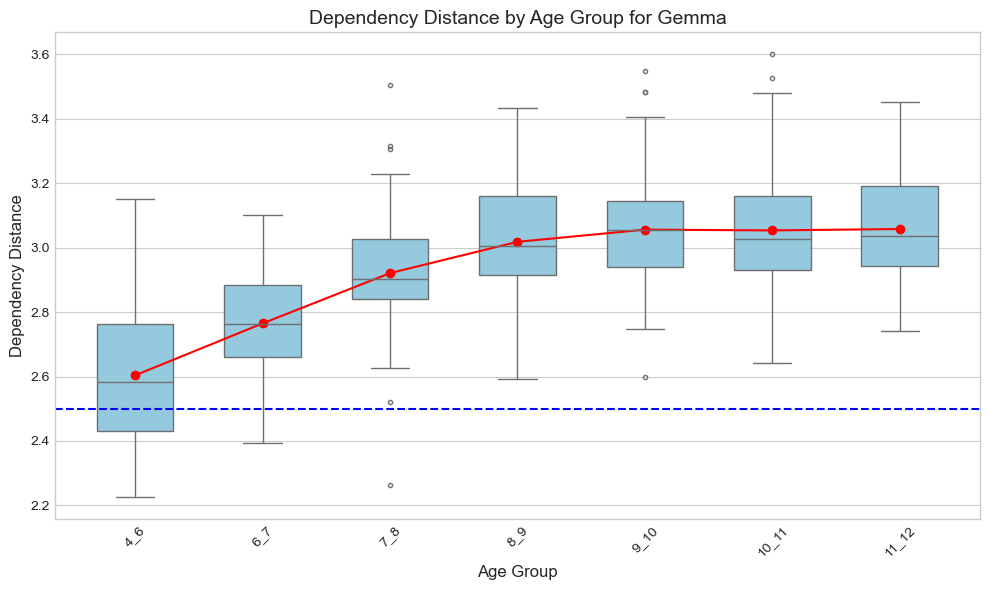

In [ ]:
# 1. Sample max 50 per age group
df_sampled = (
    age_gemma.groupby("age", group_keys=False)
      .apply(lambda x: x.sample(n=min(50, len(x)), random_state=42))
)

# 2. Sort age groups numerically by their lower bound
# Extract the lower bound as an integer
age_order = (
    df_sampled["age"]
    .unique()
)
age_order = sorted(age_order, key=lambda x: int(x.split("_")[0]))

# 3. Create box plot with sorted x-axis
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_sampled[['age', 'DD']],
    x="age",
    y="DD",
    order=age_order,   # sorted order here
    color="skyblue",
    fliersize=3,
    width=0.6
)

# 5. Add trend line (mean per age group)
# 3. Compute mean dependency distance per age group (for trend line)
mean_values = (
    df_sampled.groupby("age")["DD"]
    .mean() 
    .reindex(age_order)
)
plt.plot(age_order, mean_values, color="red", marker="o", linestyle="-", label="Mean trend")

# 6. Add horizontal reference line at y=2.5
plt.axhline(y=2.5, color="blue", linestyle="--", linewidth=1.5, label="y = 2.5")


# 4. Aesthetics
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Dependency Distance", fontsize=12)
plt.title("Dependency Distance by Age Group for Gemma", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_25867/1993995806.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(50, len(x)), random_state=42))


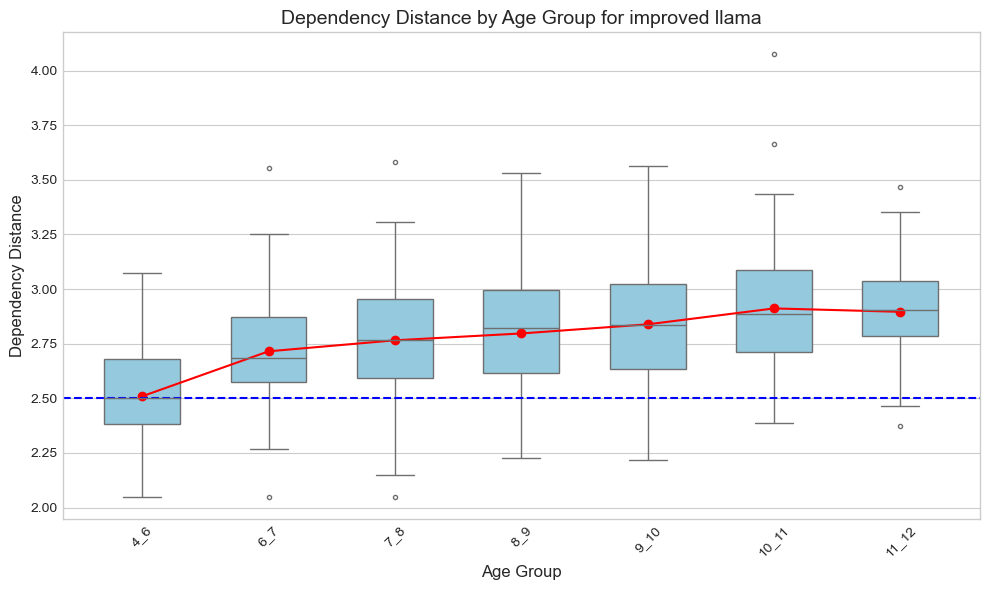

In [43]:
# 1. Sample max 50 per age group
df_sampled = (
    age_improved_llama.groupby("age", group_keys=False)
      .apply(lambda x: x.sample(n=min(50, len(x)), random_state=42))
)

# 2. Sort age groups numerically by their lower bound
# Extract the lower bound as an integer
age_order = (
    df_sampled["age"]
    .unique()
)
age_order = sorted(age_order, key=lambda x: int(x.split("_")[0]))

# 3. Create box plot with sorted x-axis
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_sampled[['age', 'DD']],
    x="age",
    y="DD",
    order=age_order,   # sorted order here
    color="skyblue",
    fliersize=3,
    width=0.6
)

# 5. Add trend line (mean per age group)
# 3. Compute mean dependency distance per age group (for trend line)
mean_values = (
    df_sampled.groupby("age")["DD"]
    .mean()
    .reindex(age_order)
)
plt.plot(age_order, mean_values, color="red", marker="o", linestyle="-", label="Mean trend")

# 6. Add horizontal reference line at y=2.5
plt.axhline(y=2.5, color="blue", linestyle="--", linewidth=1.5, label="y = 2.5")


# 4. Aesthetics
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Dependency Distance", fontsize=12)
plt.title("Dependency Distance by Age Group for improved llama", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_25867/2027846750.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(50, len(x)), random_state=42))


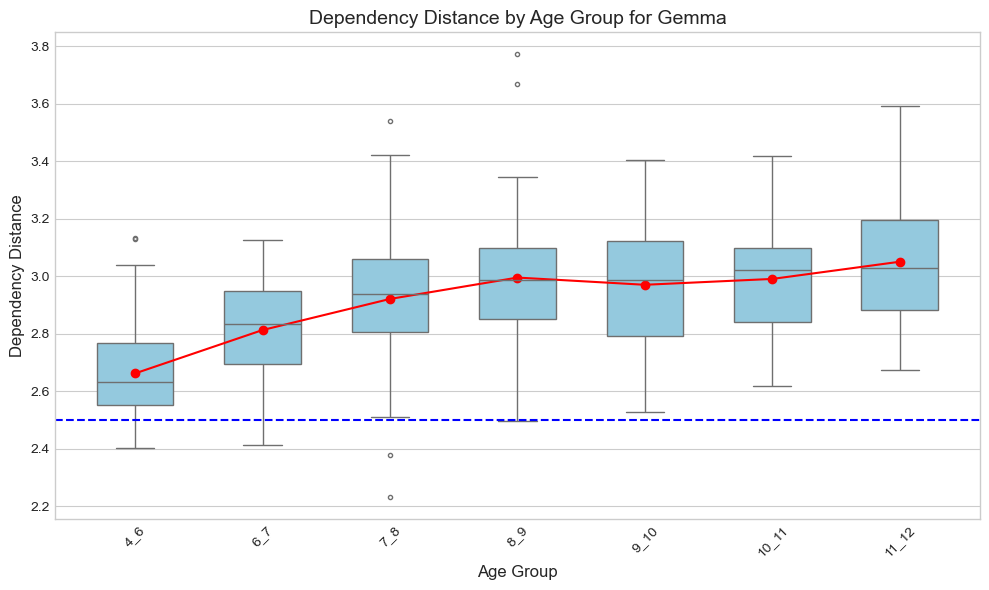

In [42]:
# 1. Sample max 50 per age group
df_sampled = (
    age_improved_gemma.groupby("age", group_keys=False)
      .apply(lambda x: x.sample(n=min(50, len(x)), random_state=42))
)

# 2. Sort age groups numerically by their lower bound
# Extract the lower bound as an integer
age_order = (
    df_sampled["age"]
    .unique()
)
age_order = sorted(age_order, key=lambda x: int(x.split("_")[0]))

# 3. Create box plot with sorted x-axis
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_sampled[['age', 'DD']],
    x="age",
    y="DD",
    order=age_order,   # sorted order here
    color="skyblue",
    fliersize=3,
    width=0.6
)

# 5. Add trend line (mean per age group)
# 3. Compute mean dependency distance per age group (for trend line)
mean_values = (
    df_sampled.groupby("age")["DD"]
    .mean()
    .reindex(age_order)
)
plt.plot(age_order, mean_values, color="red", marker="o", linestyle="-", label="Mean trend")

# 6. Add horizontal reference line at y=2.5
plt.axhline(y=2.5, color="blue", linestyle="--", linewidth=1.5, label="y = 2.5")


# 4. Aesthetics
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Dependency Distance", fontsize=12)
plt.title("Dependency Distance by Age Group for Gemma", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Analysis narrative elments in prompt

In [24]:
cr_without = compression_ratio(df_zero['completion'].to_list(), algorithm='gzip')
print(f"Compression Ratio Without: {cr_without:.4f}")

cr_with_elements = compression_ratio(df_nonzero['completion'].to_list(), algorithm='gzip')
print(f"Compression Ratio With: {cr_with_elements:.4f}")

Compression Ratio Without: 3.1110
Compression Ratio With: 3.0110


In [27]:
vs_without = text_utils.embedding_vendi_score(list(map(str, df_zero['completion'].to_list())), model_path='jegormeister/bert-base-dutch-cased')
vs_with = text_utils.embedding_vendi_score(list(map(str, df_nonzero['completion'].to_list())), model_path='jegormeister/bert-base-dutch-cased')
print(f'Vendi score without: {vs_without}')
print(f'Vendi score with: {vs_with}')

Vendi score without: 7.644643306732178
Vendi score with: 12.192631721496582


In [22]:
df_zero['vendi'] = df_zero.apply(lambda row: eval_f.run_component('vendi_embeddings', row['completion']), axis = 1) 
df_nonzero['vendi'] = df_nonzero.apply(lambda row: eval_f.run_component('vendi_embeddings', row['completion']), axis = 1) 

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_68463/3130695341.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


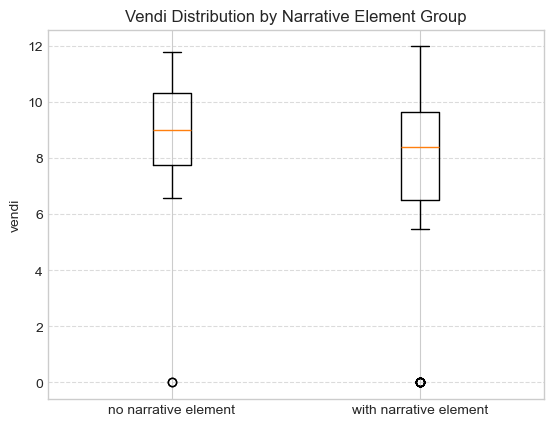

In [30]:
plt.boxplot(
    [df_zero["vendi"], df_nonzero["vendi"]],
    labels=["no narrative element", "with narrative element"]
)

plt.ylabel("vendi")
plt.title("Vendi Distribution by Narrative Element Group")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

## Analysis themes in prompt

In [34]:
cr_without = compression_ratio(df_zero_theme['completion'].to_list(), algorithm='gzip')
print(f"Compression Ratio Without: {cr_without:.4f}")

cr_with_elements = compression_ratio(df_theme['completion'].to_list(), algorithm='gzip')
print(f"Compression Ratio With: {cr_with_elements:.4f}")

Compression Ratio Without: 3.1400
Compression Ratio With: 2.9760


In [35]:
vs_without = text_utils.embedding_vendi_score(list(map(str, df_zero_theme['completion'].to_list())), model_path='jegormeister/bert-base-dutch-cased')
vs_with = text_utils.embedding_vendi_score(list(map(str, df_theme['completion'].to_list())), model_path='jegormeister/bert-base-dutch-cased')
print(f'Vendi score without: {vs_without}')
print(f'Vendi score with: {vs_with}')

Vendi score without: 6.777388572692871
Vendi score with: 9.055164337158203


In [36]:
df_zero_theme['vendi'] = df_zero_theme.apply(lambda row: eval_f.run_component('vendi_embeddings', row['completion']), axis = 1) 
df_theme['vendi'] = df_theme.apply(lambda row: eval_f.run_component('vendi_embeddings', row['completion']), axis = 1) 

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_68463/1095061973.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


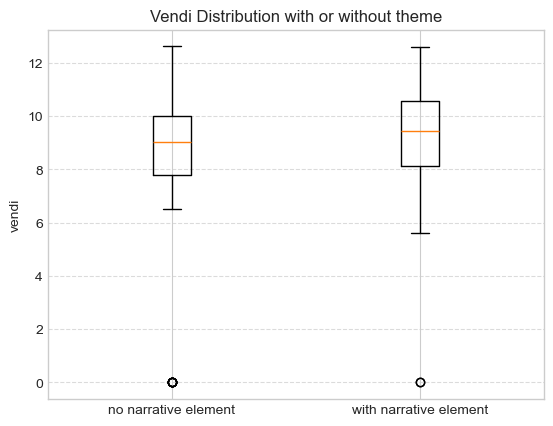

In [44]:
plt.boxplot(
    [df_zero_theme["vendi"], df_theme["vendi"]],
    labels=["no narrative element", "with narrative element"],
)

plt.ylabel("vendi")
plt.title("Vendi Distribution with or without theme")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

## Analysis words in prompt

In [47]:
cr_without = compression_ratio(df_zero_addition['completion'].to_list(), algorithm='gzip')
print(f"Compression Ratio Without: {cr_without:.4f}")

cr_with_elements = compression_ratio(df_awords['completion'].to_list(), algorithm='gzip')
print(f"Compression Ratio With: {cr_with_elements:.4f}")

Compression Ratio Without: 3.0800
Compression Ratio With: 3.0500


In [48]:
vs_without = text_utils.embedding_vendi_score(list(map(str, df_zero_addition['completion'].to_list())), model_path='jegormeister/bert-base-dutch-cased')
vs_with = text_utils.embedding_vendi_score(list(map(str, df_awords['completion'].to_list())), model_path='jegormeister/bert-base-dutch-cased')
print(f'Vendi score without: {vs_without}')
print(f'Vendi score with: {vs_with}')

Vendi score without: 7.14676570892334
Vendi score with: 11.406282424926758


In [94]:
df_zero_addition['vendi'] = df_zero_addition.apply(lambda row: eval_f.run_component('vendi_embeddings', row['completion']), axis = 1) 
df_awords['vendi'] = df_awords.apply(lambda row: eval_f.run_component('vendi_embeddings', row['completion']), axis = 1) 
baseline_data_short['vendi'] = baseline_data_short.apply(lambda row: eval_f.run_component('vendi_embeddings', row['completion']), axis = 1) 

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/3461155907.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  baseline_data_short['vendi'] = baseline_data_short.apply(lambda row: eval_f.run_component('vendi_embeddings', row['completion']), axis = 1)


/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/131374005.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


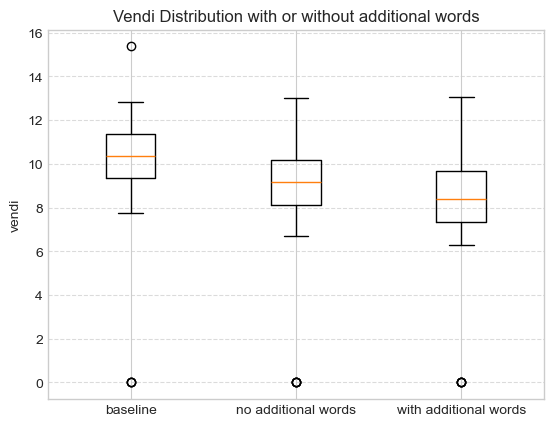

In [95]:
plt.boxplot(
    [baseline_data_short['vendi'], df_zero_addition["vendi"], df_awords["vendi"]],
    labels=["baseline", "no additional words", "with additional words"],
)

plt.ylabel("vendi")
plt.title("Vendi Distribution with or without additional words")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

## Grammaticaliteit van verschillende prompt manieren

In [73]:
df_zero_addition['gramm'] = df_zero_addition.apply(lambda row: eval_f.run_component('grammaticality', row['completion']), axis = 1) 
df_awords['gramm'] = df_awords.apply(lambda row: eval_f.run_component('grammaticality', row['completion']), axis = 1) 
df_theme['gramm'] = df_theme.apply(lambda row: eval_f.run_component('grammaticality', row['completion']), axis = 1) 
df_nonzero['gramm'] = df_nonzero.apply(lambda row: eval_f.run_component('grammaticality', row['completion']), axis = 1)
df_pos['gramm'] = df_pos.apply(lambda row: eval_f.run_component('grammaticality', row['completion']), axis = 1)

In [70]:
df_zero_addition['gramm_written'] = df_zero_addition.apply(lambda row: eval_f.run_component('grammaticality', row['completion']), axis = 1) 
df_awords['gramm_written'] = df_awords.apply(lambda row: eval_f.run_component('grammaticality', row['completion']), axis = 1) 
df_theme['gramm_written'] = df_theme.apply(lambda row: eval_f.run_component('grammaticality', row['completion']), axis = 1) 
df_nonzero['gramm_written'] = df_nonzero.apply(lambda row: eval_f.run_component('grammaticality', row['completion']), axis = 1)
df_pos['gramm_written'] = df_pos.apply(lambda row: eval_f.run_component('grammaticality', row['completion']), axis = 1)

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/2266566839.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


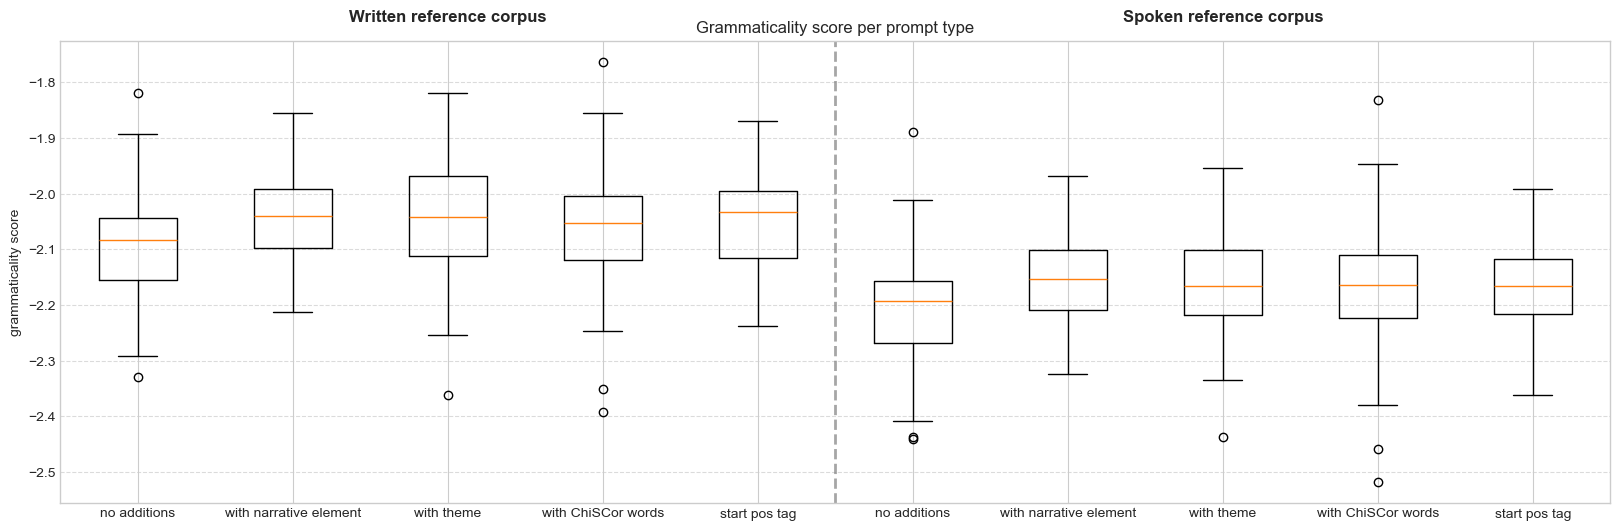

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))

# Create the boxplot
plt.boxplot(
    [
        df_zero_addition['gramm_written'], df_awords['gramm_written'],
        df_theme['gramm_written'], df_nonzero['gramm_written'],
        df_pos['gramm_written'],
        df_zero_addition['gramm'], df_awords['gramm'],
        df_theme['gramm'], df_nonzero['gramm'], df_pos['gramm']
    ],
    labels=[
        "no additions", "with narrative element", "with theme", "with ChiSCor words", "start pos tag",
        "no additions", "with narrative element", "with theme", "with ChiSCor words", "start pos tag"
    ]
)

# Add labels, title, and grid
plt.ylabel("grammaticality score")
plt.title("Grammaticality score per prompt type")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add a vertical separator between the first 5 and last 5 boxes
plt.axvline(x=5.5, color='gray', linestyle='--', linewidth=2, alpha=0.7)

# Optional: annotate the groups for clarity
plt.text(3, plt.ylim()[1]*0.98, "Written reference corpus", ha='center', fontsize=12, weight='bold')
plt.text(8, plt.ylim()[1]*0.98, "Spoken reference corpus", ha='center', fontsize=12, weight='bold')

plt.show()

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_68463/2876005135.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


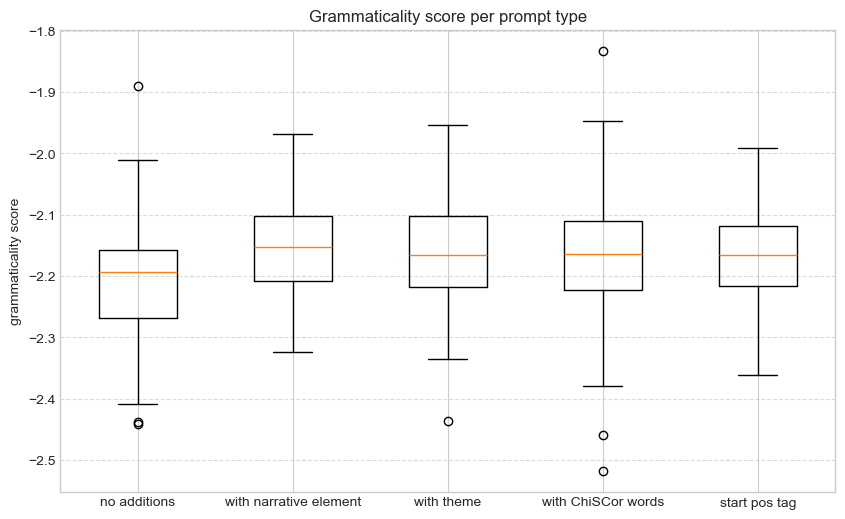

In [124]:
plt.figure(figsize=(10, 6))
plt.boxplot(
    [df_zero_addition['gramm'], df_awords['gramm'], df_theme['gramm'], df_nonzero['gramm'], df_pos['gramm']],
    labels=["no additions", "with narrative element", "with theme", "with ChiSCor words", "start pos tag"]
)

plt.ylabel("grammaticality score")
plt.title("Grammaticality score per prompt type")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [66]:
df_awords[df_awords['gramm'] == df_awords['gramm'].min()] 

,model,theme,system,user,completion,vendi,gramm
1,meta-llama/llama-3.1-8b-instruct,plekje_dichtbij_aanbellen,\nJe bent een verteller van een kort verhaal (...,Vertel een verhaal. \nHet verhaal moet het vol...,Er was eens een leuke vos. Hij heette Vosje. V...,10.307737,-2.323293


## Constrained pos tag

In [56]:
cr_without = compression_ratio(df_zero_pos['completion'].to_list(), algorithm='gzip')
print(f"Compression Ratio Without: {cr_without:.4f}")

cr_with_elements = compression_ratio(df_pos['completion'].to_list(), algorithm='gzip')
print(f"Compression Ratio With: {cr_with_elements:.4f}")

Compression Ratio Without: 3.0690
Compression Ratio With: 2.9610


In [57]:
vs_without = text_utils.embedding_vendi_score(list(map(str, df_zero_pos['completion'].to_list())), model_path='jegormeister/bert-base-dutch-cased')
vs_with = text_utils.embedding_vendi_score(list(map(str, df_pos['completion'].to_list())), model_path='jegormeister/bert-base-dutch-cased')
print(f'Vendi score without: {vs_without}')
print(f'Vendi score with: {vs_with}')

Vendi score without: 8.050919532775879
Vendi score with: 8.280613899230957


In [58]:
df_zero_pos['vendi'] = df_zero_pos.apply(lambda row: eval_f.run_component('vendi_embeddings', row['completion']), axis = 1) 
df_pos['vendi'] = df_pos.apply(lambda row: eval_f.run_component('vendi_embeddings', row['completion']), axis = 1) 

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_68463/1522634770.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


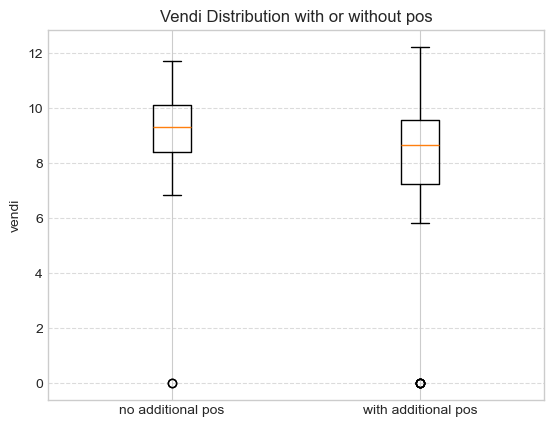

In [59]:
plt.boxplot(
    [df_zero_pos["vendi"], df_pos["vendi"]],
    labels=["no additional pos", "with additional pos"],
)

plt.ylabel("vendi")
plt.title("Vendi Distribution with or without pos")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [75]:
df_pos = df_pos.rename({'theme': 'pos'}, axis=1)

In [86]:
ADV_stories = df_pos[df_pos['pos'] == 'ADV']
PRON_stories = df_pos[df_pos['pos'] == 'PRON']


In [90]:
df_pos['pos'].unique()

array(['ADV', 'PRON', 'CCONJ'], dtype=object)

In [88]:
counter = 0
for row in df_pos['completion']:
    cleaned = row.strip('\n').lower().split(' ')
    if cleaned[0] == 'er':
        counter += 1
counter

0

In [111]:
df_all_pos = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/prompting/prompting_results/erinvestigation_research_prompting_llama3-8b.csv')
completion_cols = ["completion1", "completion2", "completion3", "completion4", "completion5"]

# ---- case 1: theme == 0 ----
df_all_pos = (
    df_all_pos[["model", "pos", "system", "user"] + completion_cols]
    .melt(id_vars=["model", "pos", "system", "user"],
          value_name="completion",
          var_name="completion_number")
    .drop(columns="completion_number")
    .reset_index(drop=True)
)

In [112]:
counter = 0
for idx, row in df_all_pos.iterrows():
    cleaned = row['completion'].strip('\n').lower().split(' ')
    if cleaned[0] == 'er':
        counter += 1
        print(row['pos'])
counter

SPACE
SPACE


2

In [117]:
df_all_pos[df_all_pos['pos'] == 'SPACE']

,model,pos,system,user,completion
8,meta-llama/llama-3.1-8b-instruct,SPACE,\nJe bent een verteller van een kort verhaal (...,Vertel een verhaal. \nBegin het verhaal met ee...,Eenmaal was er een prinsesje genaamd Sophie. Z...
23,meta-llama/llama-3.1-8b-instruct,SPACE,\nJe bent een verteller van een kort verhaal (...,Vertel een verhaal. \nBegin het verhaal met ee...,"In een heel klein dorpje, waar ik graag zou wi..."
38,meta-llama/llama-3.1-8b-instruct,SPACE,\nJe bent een verteller van een kort verhaal (...,Vertel een verhaal. \nBegin het verhaal met ee...,Er waren eens drie prinsessen. Ze woonden in e...
53,meta-llama/llama-3.1-8b-instruct,SPACE,\nJe bent een verteller van een kort verhaal (...,Vertel een verhaal. \nBegin het verhaal met ee...,"Er was eens een prinsesje dat in een grote, mo..."
68,meta-llama/llama-3.1-8b-instruct,SPACE,\nJe bent een verteller van een kort verhaal (...,Vertel een verhaal. \nBegin het verhaal met ee...,Eenmaal was er een prinsesje die in een mooi k...


## Analysis surprise

In [77]:
baseline_data_short = baseline_data[:50]

In [82]:
df_zero_addition['surprise'] = df_zero_addition.apply(lambda row: compute_surprise(row['completion'])[0], axis = 1) 
df_awords['surprise'] = df_awords.apply(lambda row: compute_surprise(row['completion'])[0], axis = 1) 
baseline_data_short['surprise'] = baseline_data_short.apply(lambda row: compute_surprise(row['completion'])[0], axis = 1) 
# df_theme['surprise'] = df_theme.apply(lambda row: compute_surprise(row['completion'])[0], axis = 1) 
# df_nonzero['surprise'] = df_nonzero.apply(lambda row: compute_surprise(row['completion'])[0], axis = 1)
# df_pos['surprise'] = df_pos.apply(lambda row: compute_surprise(row['completion'])[0], axis = 1)

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/4102508777.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  baseline_data_short['surprise'] = baseline_data_short.apply(lambda row: compute_surprise(row['completion'])[0], axis = 1)


In [224]:
df_zero_addition['completion'][df_zero_addition['surprise'] == df_zero_addition['surprise'].max()]

3    Er was eens een prinses met een paard dat kon ...
Name: completion, dtype: object

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/30932949.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


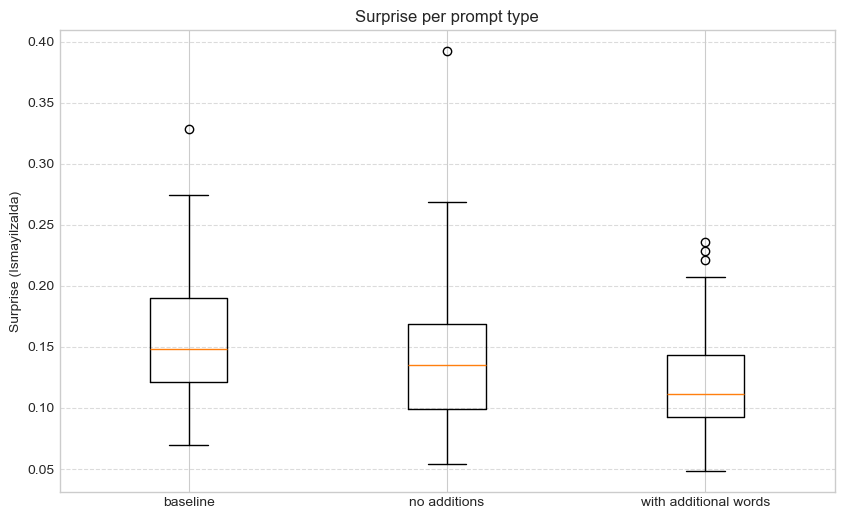

In [107]:
plt.figure(figsize=(10, 6))
plt.boxplot(
    [baseline_data_short['surprise'], df_zero_addition['surprise'], df_awords['surprise']],
    labels=["baseline", "no additions", "with additional words"]
)

plt.ylabel("Surprise (Ismayilzalda)")
plt.title("Surprise per prompt type")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [229]:
df_zero_addition['c_ppl'] = df_zero_addition.apply(lambda row: eval_f.run_component('creative_perplexity_bigram_constrained', row['completion']), axis = 1) 
df_awords['c_ppl'] = df_awords.apply(lambda row: eval_f.run_component('creative_perplexity_bigram_constrained', row['completion']), axis = 1) 
baseline_data['c_ppl'] = baseline_data.apply(lambda row: eval_f.run_component('creative_perplexity_bigram_constrained', row['completion']), axis = 1) 

In [108]:
plt.figure(figsize=(20, 6))
plt.boxplot(
    [baseline_data['c_ppl'], df_zero_addition['c_ppl'], df_awords['c_ppl']],
    labels=["baseline", "no additions", "with additional words"]
)

plt.ylabel("Creative perplexity")
plt.title("Creative perplexity per prompt type")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

KeyError: 'c_ppl'

<Figure size 2000x600 with 0 Axes>

## Doorontwikkeling creative perplexity

In [102]:
import pandas as pd
from pathlib import Path
from collections import Counter
import numpy as np
from simplemma import text_lemmatizer

class CreativePerplexity():
    def __init__(self, nlp, mode, unigram, bigram, constrained_bigram):
        self.nlp = nlp
        self.mode = mode
        self.unigram = self._load_reference_corpora(unigram)
        self.bigram = self._load_reference_corpora(bigram)
        self.constrained_bigram = self._load_reference_corpora(constrained_bigram)

    def _load_reference_corpora(self, data_path: str) -> pd.DataFrame:
        if Path(data_path).exists():
            return pd.read_csv(data_path)
        
        raise Exception(f'Reference corpora are not registered.')
    
    def _extract_unigrams(self, story, *, with_pos=False,
                     include_punct=False, include_space=False, exclude_pos=None) -> Counter:
        """
        Return Counter of (lemma,) or (lemma,pos) from the story.
        """
        doc = self.nlp(story)
        bag = Counter()
        for t in doc:
            if not include_space and t.is_space: 
                continue
            if not include_punct and t.is_punct: 
                continue
            if exclude_pos and t.pos_ in exclude_pos:
                continue
            if with_pos:
                bag[(t.lemma_, t.pos_)] += 1
            else:
                bag[(t.lemma_,)] += 1
        return bag

    def _extract_bigrams(self, story):
        """
        Return Counter of (lemma_{i-1}, lemma_i) from the story.
        """
        doc = self.nlp(story)
        pairs = [(doc[i].lemma_, doc[i+1].lemma_) for i in range(len(doc)-1)]

        return Counter(pairs)

    def _collect_dep_pairs(self, node, bag: Counter):
        """
        Collect linguistically constrained pairs.
        Here: (child -> head) for selected relations.
        Adjust the rules to your needs, but keep orientation consistent with lexicon.
        """
        # Verbal heads: subject/object relations
        if node.pos_ in ('VERB', 'AUX'):
            for child in node.children:
                if child.dep_ in ('nsubj', 'nsubj:pass', 'obj') and (child.pos_ != "PROPN" and child.pos_ != "PRON"):
                    # bag[(child.lemma_, node.lemma_, child.pos_, node.pos_, child.dep_, node.dep_)] += 1
                    child_lemma = text_lemmatizer(child.text, lang='nl')[0]
                    node_lemma = text_lemmatizer(node.text, lang='nl')[0]
                    bag[(child_lemma, node_lemma)] += 1

        # Nominal heads: adjectival modifiers
        if node.pos_ == 'NOUN':
            for child in node.children:
                if child.dep_ == 'amod' and child.pos_ == 'ADJ':
                    child_lemma = text_lemmatizer(child.text, lang='nl')[0]
                    node_lemma = text_lemmatizer(node.text, lang='nl')[0]
                    bag[(child_lemma, node_lemma)] += 1

        # Recurse
        for child in node.children:
            self._collect_dep_pairs(child, bag)

    def _extract_dep_pairs(self, story):
        """
        Return Counter of linguistically constrained (lemma1, lemma2) pairs.
        Current orientation: (dependent lemma, head lemma).
        """
        bag = Counter()
        for sent in self.nlp(story).sents:
            self._collect_dep_pairs(sent.root, bag)
        return bag

    def _compute_unigram_perplexity_from_counts(
        self,
        story_counts: Counter,
        lexicon,
        *,
        cols=("lemma",),                # or ("lemma","pos")
        alpha: float = 1.0,
        return_frame: bool = False,
    ):
        """
        Unigram PPL with Laplace smoothing:
        p(w) = (c_corpus(w) + alpha) / (C + alpha*V)
        Weighted by story token counts.
        """
        if not story_counts:
            return (None, pd.DataFrame(columns=[*cols,"count","freq"])) if return_frame else None

        story_df = pd.DataFrame([(*k, c) for k, c in story_counts.items()],
                                columns=[*cols, "count"]) \
                .merge(lexicon, how="left", on=list(cols))
        story_df["freq"] = story_df["freq"].fillna(0).astype(np.int64)

        C = int(lexicon["freq"].sum())                                # total tokens in reference
        V = int(lexicon.drop(columns=["freq"]).drop_duplicates().shape[0]) or 1
        denom = C + alpha * V

        p = (story_df["freq"] + alpha) / denom
        logp = np.log(p)

        N = int(story_df["count"].sum())
        ppl = float(np.exp(-(logp * story_df["count"]).sum() / N))

        if return_frame:
            out = story_df.copy()
            out["prob"] = p
            return ppl, out[[*cols, "count", "freq", "prob"]]
        return ppl

    def _compute_perplexity_from_counts(
        self,
        story_counts: Counter,
        lex: pd.DataFrame,       
        *,
        smoothing: str = "kneser_ney",   
        alpha: float = 0.1,              
        unk_token: str = "<unk>",
        return_frame: bool = False
    ):
        
        # Fixed vocab for lemma2 (after cutoff)
        vocab2 = set(lex['lemma2'].unique())
        global_V = len(vocab2)

        # ---------- 2) Prepare story pairs and map OOV lemma2 → <unk> ----------
        if not story_counts:
            return (None, pd.DataFrame(columns=['lemma1','lemma2','count'])) if return_frame else None

        def map_l2(l2):
            return l2 if l2 in vocab2 else unk_token

        story_pairs = [ (l1, map_l2(l2), c) for (l1, l2), c in story_counts.items() ]
        story_df = pd.DataFrame(story_pairs, columns=['lemma1','lemma2','count'])

        # Merge training counts for these pairs
        story_df = story_df.merge(lex, how='left', on=['lemma1','lemma2'])
        story_df['freq'] = story_df['freq'].fillna(0).astype(int)

        # Totals per history
        hist_totals = lex.groupby('lemma1', as_index=False)['freq'].sum().rename(columns={'freq':'hist_total'})
        story_df = story_df.merge(hist_totals, how='left', on='lemma1')
        story_df['hist_total'] = story_df['hist_total'].fillna(0).astype(int)

        # ---------- 3A) Kneser–Ney smoothing ----------
        if smoothing == "kneser_ney":
            # Continuation counts (#distinct w1 per w2)
            cont_df = (
                lex[lex['freq'] > 0]
                .groupby('lemma2', as_index=False)['lemma1']
                .nunique()
                .rename(columns={'lemma1':'cont_count'})
            )
            cont_df = pd.DataFrame({'lemma2': list(vocab2)}).merge(cont_df, how='left', on='lemma2')
            cont_df['cont_count'] = cont_df['cont_count'].fillna(0).astype(int)

            total_types = int((lex['freq'] > 0).sum())
            cont_df['p_cont'] = np.where(
                total_types > 0,
                cont_df['cont_count'] / total_types,
                1.0 / global_V
            )

            story_df = story_df.merge(cont_df[['lemma2','p_cont']], how='left', on='lemma2')
            story_df['p_cont'] = story_df['p_cont'].fillna(1.0 / global_V)

            # Distinct followers per history
            T_df = (
                lex[lex['freq'] > 0]
                .groupby('lemma1', as_index=False)['lemma2']
                .nunique()
                .rename(columns={'lemma2':'T_followers'})
            )
            story_df = story_df.merge(T_df, how='left', on='lemma1')
            story_df['T_followers'] = story_df['T_followers'].fillna(0).astype(int)

            # Discount D
            counts = lex['freq'].values
            N1 = int(np.sum(counts == 1))
            N2 = int(np.sum(counts == 2))
            D = (N1 / (N1 + 2 * N2)) if (N1 + 2 * N2) > 0 else 0.75

            lam = np.where(
                story_df['hist_total'] > 0,
                (D * story_df['T_followers']) / story_df['hist_total'].clip(lower=np.finfo(float).tiny),
                1.0  # unseen history → full backoff
            )

            first_term = np.where(
                story_df['hist_total'] > 0,
                np.maximum(story_df['freq'] - D, 0.0) / story_df['hist_total'].clip(lower=np.finfo(float).tiny),
                0.0
            )

            probs = first_term + lam * story_df['p_cont']
            probs = np.maximum(probs, np.finfo(float).tiny)

            diag_cols = ['lemma1','lemma2','count','freq','hist_total','T_followers','p_cont']
            story_df_out = story_df[diag_cols].copy()
            story_df_out['prob'] = probs

        # ---------- 3B) Add-α smoothing (global) ----------
        elif smoothing == "add_alpha":
            uni = lex.groupby('lemma2', as_index=False)['freq'].sum().rename(columns={'freq':'uni_count'})
            uni = pd.DataFrame({'lemma2': list(vocab2)}).merge(uni, how='left', on='lemma2')
            uni['uni_count'] = uni['uni_count'].fillna(0).astype(int)
            total_uni = int(uni['uni_count'].sum())
            uni['p_unigram'] = (uni['uni_count'] + alpha) / (total_uni + alpha * global_V)

            story_df = story_df.merge(uni[['lemma2','p_unigram']], how='left', on='lemma2')

            denom = story_df['hist_total'] + alpha * global_V
            denom = denom.replace(0, np.nan)  # unseen histories → NaN
            bigram_probs = (story_df['freq'] + alpha) / denom
            probs = bigram_probs.fillna(story_df['p_unigram'])  # backoff to unigram
            probs = np.maximum(probs, np.finfo(float).tiny)

            diag_cols = ['lemma1','lemma2','count','freq','hist_total']
            story_df_out = story_df[diag_cols].copy()
            story_df_out['prob'] = probs

        else:
            raise ValueError("smoothing must be 'kneser_ney' or 'add_alpha'")
        print(story_df)
        # ---------- 4) Compute perplexity ----------
        N = int(story_df['count'].sum())
        if N == 0:
            return (None, story_df_out) if return_frame else None

        avg_logp = (np.log(probs) * story_df['count']).sum() / N
        ppl = float(np.exp(-avg_logp))

        if return_frame:
            return ppl, story_df_out
        return ppl

    def _perplexity_for_creativity(
        self,
        story: str,
        *,
        alpha: float,
        vocab: str,    # for bigrams only: "global" or "per_history"
        with_pos_unigram: bool,   # unigram extractor option
        unigram_cols,        # or ("lemma","pos") to match your lexicon
        return_frame: bool,
    ):
        """
        General entry point. Chooses the extractor and computes perplexity.
        IMPORTANT: Your lexicon columns must match the extractor/cols:
        - unigram_cols for 'unigram'
        - ['lemma1','lemma2','freq'] for 'bigram'/'dep'
        """
        if self.mode == "bigram":
            counts = self._extract_bigrams(story)
            return self._compute_perplexity_from_counts(
                counts, self.bigram, alpha=alpha, vocab=vocab, return_frame=return_frame
            )
        elif self.mode == "dep":
            counts = self._extract_dep_pairs(story)
            print(counts)
            return self._compute_perplexity_from_counts(
                counts, self.constrained_bigram, alpha=alpha, return_frame=return_frame
            )
        elif self.mode == "unigram":
            counts = self._extract_unigrams(story, with_pos=with_pos_unigram)
            return self._compute_unigram_perplexity_from_counts(
                counts, self.unigram, cols=unigram_cols, alpha=alpha, return_frame=return_frame
            )
        else:
            raise ValueError("mode must be 'unigram', 'bigram', or 'dep'")
    
    def evaluate(self, text: str, vocab="per_history", alpha=1.0, with_pos_unigram=True,
                 unigram_cols=("lemma","pos"), return_frame=False
                 ) -> float:
        return self._perplexity_for_creativity(text,
                                               vocab=vocab,
                                               alpha=alpha,
                                               with_pos_unigram=with_pos_unigram,
                                               unigram_cols=unigram_cols,
                                               return_frame=return_frame
                                               )

In [103]:
ref_standard_dep = Path('datasets/BasiScript/BS_dep_lexicon_unk_newlemmatizer_nopronoun.csv')
ref_standard_uni = Path('datasets/BasiScript/BS_unigram_lexicon.csv')
ref_standard_bi = Path('datasets/BasiScript/BS_bigram_lexicon.csv')

#  nlp, mode, unigram, bigram, constrained_bigram
ppl = CreativePerplexity(nlp, 'dep', ref_standard_uni, ref_standard_bi, ref_standard_dep)

In [104]:
highest_score = baseline_data_short['completion'].iloc[4]

In [105]:
ppl.evaluate(highest_score)

Counter({('steen', 'gooien'): 2, ('konijn', 'wonen'): 1, ('kleine', 'konijn'): 1, ('mooi', 'tuinen'): 1, ('kleurig', 'bloem'): 1, ('groot', 'putten'): 1, ('eend', 'komen'): 1, ('vriendelijk', 'eend'): 1, ('tak', 'gooien'): 1, ('lang', 'tak'): 1, ('floppen', 'grijpen'): 1, ('tak', 'grijpen'): 1})
         lemma1   lemma2  count  Unnamed: 0  freq  hist_total    p_cont  \
0        konijn    wonen      1         NaN     0         683  0.002203   
1        kleine   konijn      1         NaN     0        3696  0.000343   
2          mooi   tuinen      1     77412.0    16        4283  0.000197   
3       kleurig    bloem      1     60308.0     1          13  0.000153   
4         groot   putten      1         NaN     0        8237  0.000022   
5          eend    komen      1     28883.0     6         142  0.018455   
6   vriendelijk     eend      1         NaN     0         392  0.000051   
7         steen   gooien      2    108125.0    13         163  0.004005   
8           tak   gooien    

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/2961675889.py:199: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  (D * story_df['T_followers']) / story_df['hist_total'].clip(lower=np.finfo(float).tiny),
/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/2961675889.py:205: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd

908.6631421485164

In [106]:
df_zero_addition['c_ppl'] = df_zero_addition.apply(lambda row: ppl.evaluate(row['completion']), axis = 1) 
df_awords['c_ppl'] = df_awords.apply(lambda row: ppl.evaluate(row['completion']), axis = 1) 
baseline_data_short['c_ppl'] = baseline_data_short.apply(lambda row: ppl.evaluate(row['completion']), axis = 1) 

Counter({('rood', 'haar'): 2, ('prinses', 'zijn'): 1, ('groot', 'kasteel'): 1, ('hond', 'hebben'): 1, ('genaamd', 'whiskers'): 1, ('prinses', 'houden'): 1, ('paard', 'helpen'): 1, ('hongeren', 'hebben'): 1, ('theepot', 'maken'): 1, ('speciaal', 'theepot'): 1, ('boodschapper', 'komen'): 1, ('koningin', 'zeggen'): 1, ('prinses', 'gaan'): 1, ('baljurk', 'hebben'): 1, ('mooi', 'baljurk'): 1})
          lemma1   lemma2  count  Unnamed: 0  freq  hist_total    p_cont  \
0        prinses     zijn      1     92592.0    41         314  0.028288   
1           rood     haar      2     97312.0     5         174  0.000401   
2          groot  kasteel      1     41721.0    44        8237  0.000212   
3           hond   hebben      1     48059.0  4083       21427  0.047998   
4        genaamd    <unk>      1     36690.0    12         109  0.009906   
5        prinses   houden      1         NaN     0         314  0.004968   
6          paard   helpen      1     85645.0     2        1334  0.002487   


/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/2961675889.py:199: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  (D * story_df['T_followers']) / story_df['hist_total'].clip(lower=np.finfo(float).tiny),
/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/2961675889.py:205: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd

Counter({('tuinen', 'hebben'): 1, ('groot', 'tuinen'): 1, ('bloem', 'zit'): 1, ('vriendin', 'hebben'): 1, ('cape', 'hebben'): 1, ('ei', 'zoeken'): 1, ('vosch', 'vinden'): 1, ('ei', 'vinden'): 1, ('ei', 'eten'): 1, ('regenwulp', 'komen'): 1, ('paraplu', 'hebben'): 1, ('drie', 'gaan'): 1, ('vosch', 'zeggen'): 1, ('wolpje', 'zeggen'): 1})
       lemma1  lemma2  count  Unnamed: 0  freq  hist_total    p_cont  \
0      tuinen  hebben      1    116912.0    83         182  0.047998   
1       groot  tuinen      1     42296.0   109        8237  0.000197   
2       bloem     zit      1         NaN     0         360  0.005318   
3    vriendin  hebben      1    126937.0   331        1433  0.047998   
4        cape  hebben      1     17987.0     5          13  0.047998   
5          ei  zoeken      1     29321.0    48        1408  0.003713   
6       vosch  vinden      1    126221.0     2           7  0.019250   
7          ei  vinden      1     29308.0    24        1408  0.019250   
8          ei 

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/2961675889.py:199: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  (D * story_df['T_followers']) / story_df['hist_total'].clip(lower=np.finfo(float).tiny),
/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/2961675889.py:205: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd

Counter({('vriend', 'zijn'): 1, ('hond', 'hebben'): 1, ('genaamd', 'buster'): 1, ('groot', 'hond'): 1, ('rode', 'hond'): 1, ('lang', 'staren'): 1, ('ballen', 'gooien'): 1, ('kisten', 'vinden'): 1, ('oud', 'kisten'): 1, ('brief', 'zitten'): 1, ('klein', 'brief'): 1, ('geheim', 'vinden'): 1, ('mooi', 'geheim'): 1, ('map', 'leiden'): 1, ('oud', 'bomen'): 1, ('feest', 'geven'): 1, ('feest', 'gooien'): 1, ('tijd', 'hebben'): 1, ('leuk', 'tijd'): 1, ('groot', 'ster'): 1})
     lemma1  lemma2  count  Unnamed: 0  freq  hist_total    p_cont  \
0    vriend    zijn      1    126853.0   173        3291  0.028288   
1      hond  hebben      1     48059.0  4083       21427  0.047998   
2   genaamd   <unk>      1     36690.0    12         109  0.009906   
3     groot    hond      1     41663.0   505        8237  0.001598   
4      rode    hond      1     96724.0     2         524  0.001598   
5      lang  staren      1     65217.0    30        1396  0.000306   
6    ballen  gooien      1      8148.0 

...

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/2961675889.py:199: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  (D * story_df['T_followers']) / story_df['hist_total'].clip(lower=np.finfo(float).tiny),
/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/2961675889.py:205: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd

             lemma1        lemma2  count  Unnamed: 0  freq  hist_total  \
0            konijn          zijn      1     61997.0    47         683   
1             klein        konijn      1     59183.0    12        1926   
2            fluffy         wonen      1         NaN     0           8   
3          prachtig        tuinen      1     92068.0     1         180   
4             groot      bebossen      1     41342.0    36        8237   
5          vriendin        vinden      2    127034.0    33        1433   
6             nieuw      vriendin      1     80709.0    40        3321   
7             klein        vijver      1     59342.0     2        1926   
8          kikkeren          zien      1     57368.0    32         340   
9          kikkeren         heten      1     57296.0     3         340   
10             goed        vriend      1     39402.0   528        6072   
11     schuilplaats     ontdekken      1         NaN     0          16   
12           geheim  schuilplaats     

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/2961675889.py:199: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  (D * story_df['T_followers']) / story_df['hist_total'].clip(lower=np.finfo(float).tiny),
/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/2961675889.py:205: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd

         lemma1  lemma2  count  Unnamed: 0  freq  hist_total    p_cont  \
0        konijn    zijn      1     61997.0    47         683  0.028288   
1        fluffy  hebben      1     33924.0     1           8  0.047998   
2        staren  hebben      1    108010.0   321         444  0.047998   
3          mooi  staren      1     77345.0     7        4283  0.000306   
4          roze  staren      1         NaN     0         175  0.000306   
5        vossen    zien      1    126259.0    21         101  0.015822   
6         groot  vossen      1         NaN     0        8237  0.000036   
7    reusachtig  vossen      1         NaN     0          37  0.000036   
8        vossen  zeggen      3    126258.0    14         101  0.013488   
9         klein  konijn      1     59183.0    12        1926  0.000343   
10    wedstrijd     ren      1    129466.0    15        1629  0.001255   
11        groot   <unk>      1     41289.0   279        8237  0.009906   
12        ander  kanten      1      50

KeyboardInterrupt: 

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/699464811.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


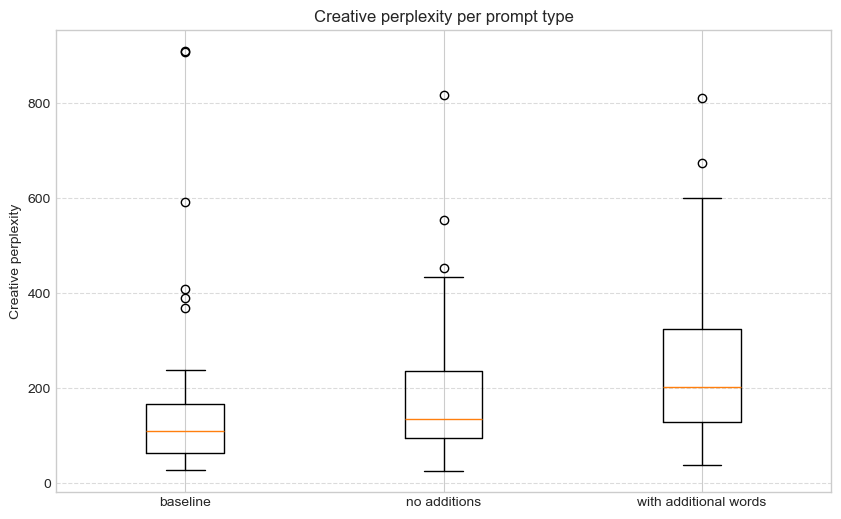

In [109]:
plt.figure(figsize=(10, 6))
plt.boxplot(
    [baseline_data_short['c_ppl'], df_zero_addition['c_ppl'], df_awords['c_ppl']],
    labels=["baseline", "no additions", "with additional words"]
)

plt.ylabel("Creative perplexity")
plt.title("Creative perplexity per prompt type")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [96]:
baseline_data_short[baseline_data_short['c_ppl'] == baseline_data_short['c_ppl'].max()]

,model,system,user,completion,surprise,c_ppl,vendi
4,meta-llama/llama-3.1-8b-instruct,\nJe bent een verteller van een kort verhaal (...,Vertel een verhaal.,Er woonde een kleine konijn. Hij heette Flop. ...,0.1523,908.663142,12.818876


In [97]:
baseline_data_short['completion'].iloc[4]

'Er woonde een kleine konijn. Hij heette Flop. Flop woonde in een mooie tuin. De tuin was vol met kleurige bloemen.\n\nFlop hield van eten. Hij hield vooral van appels. Hij ging naar de boom om te eten. Maar toen hij naar de boom liep, viel hij in een grote put.\n\nFlop was bang. Hij wist niet hoe hij uit de put moest klimmen. Maar hij was niet alleen. Er kwam een vriendelijke eend naar de put. Ze heette Elex.\n\nElex zei: "Gooi een steen in de put. Dan zie ik hoe diep hij is!" Flop gooide een steen. Elex zag hoe diep hij was.\n\nToen gooide Elex een lange tak in de put. Flop greep de tak vast. Hij klimde eruit. Flop was blij. Hij dankte Elex. Elex glimlachte.'

In [ ]:
from simplemma import text_lemmatizer

highest_score = baseline_data.iloc[36]['completion']
text_lemmatizer('cakes', lang='nl')

['cake']

## Word2Vec experiment

In [24]:
from gensim.models import Word2Vec
# from gensim.models.doc2vec import TaggedDocument
# from gensim.models import Doc2Vec
from sklearn.manifold import TSNE
from simplemma import text_lemmatizer
from adjustText import adjust_text

In [5]:
df_chiscor.head()

,id,story_lemmatized,story_raw,story_raw_no_newlines,story_no,chardepth,labels,labels_int,agegroup,treedepth_WNU,...,wbr_avg,msTTR,maTTR,MTLD,MTLD_mov,MTLD_bi,HDD,story_PP,dep_dist,agegroup_str
0,10101,er zijn er eens een meisje ze willen heel gra...,er was er eens een meisje.\nze wou heel graag ...,er was er eens een meisje. ze wou heel graag b...,1,8,person,3,5,2.166667,...,1.166667,0.975,0.987500,37.440972,33.829268,28.065789,0.000000,1.828681,1.970588,8-9
1,10201,er zijn eens een klas en die heten de en er z...,d'r was eens een klas en die heette de Golfvis...,d'r was eens een klas en die heette de Golfvis...,1,4,agent,2,5,3.000000,...,2.142857,0.900,0.908696,18.333333,19.781818,17.816611,0.547199,4.097504,2.285714,8-9
2,10202,er waren eens hand alleen die gaan op de comp...,d'r waren eens handen. \nalleen die gingen op ...,d'r waren eens handen. alleen die gingen op de...,2,5,agent,2,5,2.000000,...,1.500000,0.950,0.914286,54.208000,46.756098,23.500000,0.782266,6.151254,2.256410,8-9
3,10301,er was een keer een eenhoorn en die was helem...,er was een keer een eenhoorn en die was helema...,er was een keer een eenhoorn en die was helema...,1,5,agent,2,1,2.750000,...,1.500000,0.850,0.861290,17.792685,18.150000,14.748148,0.000000,2.713967,2.771429,4-6
4,10401,een keer naar de naar eng achtbaan toen gebeu...,een keer naar de Efteling naar enge achtbanen....,een keer naar de Efteling naar enge achtbanen....,1,3,agent,2,3,1.833333,...,1.333333,0.900,0.940741,36.000000,30.388889,23.466667,0.000000,4.502111,2.062500,6-7


In [ ]:
# function to clean raw stories
def lemmatize(data):
    sents = []
    for story in data:
        lines = list(nlp(story).sents)
        for sent in lines:
            words = [w.lemma_.lower() for w in sent if w.is_alpha]
            sents.append(words)

    return sents

def train_and_save_w2v(data, save_name):
    if Path(save_name).exists():
        return Word2Vec.load(save_name)

    # list of sents of all stories
    sents = lemmatize(data)
    # train w2v
    model = Word2Vec(sents, 
                        min_count=10, 
                        window=5, 
                        vector_size=100, 
                        negative=5, 
                        seed=42, 
                        workers=1, 
                        sg=0, 
                        alpha=0.001, 
                        epochs=500)
    
    model.save(save_name)

    return model


In [ ]:
# initialise word2vec model
model_CS = train_and_save_w2v(df_chiscor['story_raw'], 'dataset_evaluation/modelasametric/story_Word2Vec_CS.kv')

Word2Vec<vocab=586, vector_size=100, alpha=0.001>


In [112]:
baseline_data = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/prompting/prompting_results/baseline_research_prompting_llama3-8b.csv')
model_syn_baseline = train_and_save_w2v(baseline_data['completion'], 'dataset_evaluation/modelasametric/story_Word2Vec_syn_baseline.kv')

In [33]:
# # these are lemmas not having large LL values that we want to plot in a 2d space
# lemmas_of_interest_comp = ['denken', 'willen', 'weten', 'wensen', 
#                       'zien', 'horen', 
#                       'vechten', 'pakken', 'vangen', 'rennen', 'springen', 'werken',
#                       'papa', 'mama', 'broer', 'zus',
#                       'huis', 'school', 'bos', 'strand', 'kasteel',
#                       'blij', 'boos', 'verdrietig', 'bang',
#                       'groot', 'sterk', 'klein', 'raar', 'eng',
#                       'daarom', 'want', 'niet', 'geen', 'maar'
#                       ] 

# KeyError: "['wensen', 'vechten', 'werken', 'broer', 'zus', 'school', 'raar', 'eng', 'daarom'] not in index"
# these are lemmas not having large LL values that we want to plot in a 2d space
lemmas_of_interest_comp = ['denken', 'willen', 'weten', 
                      'zien', 'horen', 
                      'pakken', 'vangen', 'rennen', 'springen',
                      'papa', 'mama',
                      'huis', 'bos', 'strand', 'kasteel',
                      'blij', 'boos', 'verdrietig', 'bang',
                      'groot', 'sterk', 'klein',
                      'want', 'niet', 'geen', 'maar'
                      ] 

### TSNE projections

In [122]:
def create_tsne_projections(model, lemmas: List, *, plotting=True, title=None, use_pretrained=False):
    vocab = list(model.wv.key_to_index)

    if use_pretrained:
        X = []
        for w in vocab:
            X.append(nlp(w).vector)
        X = np.array(X)
    else:
        X = model.wv[vocab]

    tsne = TSNE(n_components=2, random_state=42, perplexity=5)
    X_tsne = tsne.fit_transform(X)

    df_tsne = pd.DataFrame(X_tsne, index=vocab, columns=['x', 'y'])
    df_tsne = df_tsne.loc[lemmas]

    if plotting:
        fig, ax = plt.subplots(figsize=(10, 4))
        sns.regplot(x='x', y='y', data=df_tsne, scatter=True, fit_reg=False, x_jitter=0.4, y_jitter=0.4)
        ax.set(xlabel='', ylabel='')
        ax.tick_params(left=True,
                        bottom=True,
                        labelleft=False,
                        labelbottom=False)
        ax.set_title(title)

        texts = []
        for x, y, word in zip(df_tsne['x'], df_tsne['y'], df_tsne.index):
            text = plt.text(x, y, word)
            texts.append(text)

        adjust_text(texts)

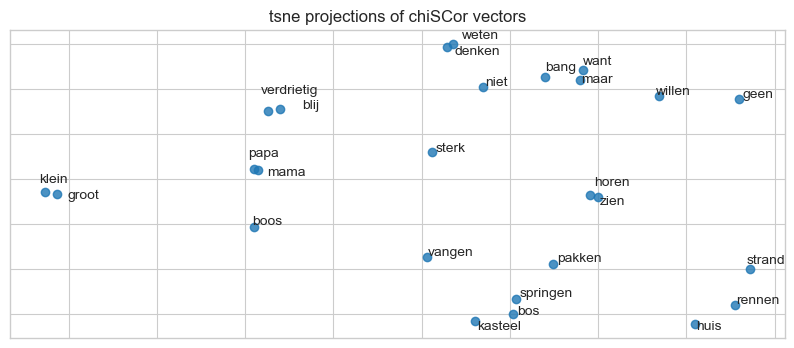

In [123]:
create_tsne_projections(model_CS, lemmas_of_interest_comp, title="tsne projections of chiSCor vectors")

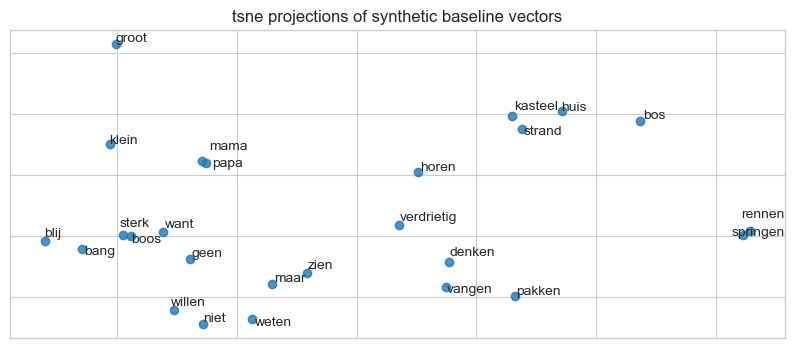

In [124]:
create_tsne_projections(model_syn_baseline, lemmas_of_interest_comp, title="tsne projections of synthetic baseline vectors")

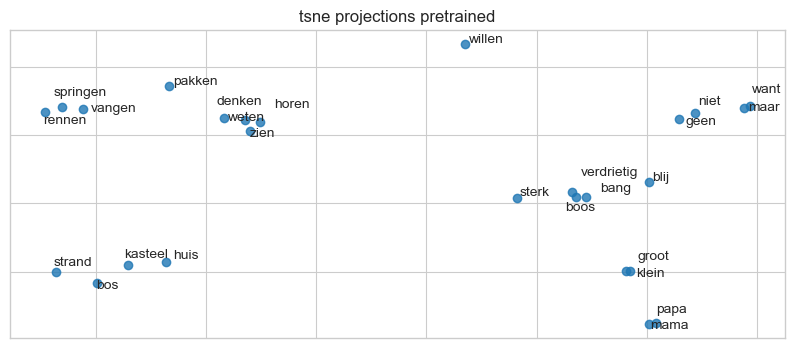

In [127]:
create_tsne_projections(model_syn_baseline, lemmas_of_interest_comp, use_pretrained=True, title="tsne projections pretrained")

### Cosine similarities with handpicked lemmas

In [148]:
def compute_similarity(lemma_list, model1, model2, *, use_pretrained=False, compare_method='cross'):

    if compare_method == 'cross':
        pairs = [(a, b) for idx, a in enumerate(lemma_list) for b in lemma_list[idx + 1:]]
    elif compare_method == 'pairwise':
        pairs = lemma_list
    else:
        raise f'Not implemented compare method'
    
    cos_sim_1 = []
    cos_sim_2 = []

    if use_pretrained:
        if not isinstance(model1, Word2Vec):
            pretrained_model = model1
        elif not isinstance(model2, Word2Vec):
            pretrained_model = model2
        else:
            raise f'Both models are custom trained, you can not use the pretrained evaluation'
        
        for pair in pairs:
            cos_sim_1.append(model1.wv.similarity(pair[0], pair[1]))
            w1 = pretrained_model(pair[0])
            w2 = pretrained_model(pair[1])
            cos_sim_2.append(w1.similarity(w2))
    else:
        for pair in pairs:
            cos_sim_1.append(model1.wv.similarity(pair[0], pair[1]))
            cos_sim_2.append(model2.wv.similarity(pair[0], pair[1]))

    return cos_sim_1, cos_sim_2

# compute correlations
cosine_sim_CS, cosine_sim_BS = compute_similarity(lemmas_of_interest_comp, model_CS, model_syn_baseline)
stats.spearmanr(cosine_sim_CS, cosine_sim_BS)

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/3723903852.py:35: DeprecationWarning: Please import `spearmanr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  stats.spearmanr(cosine_sim_CS, cosine_sim_BS)


SignificanceResult(statistic=0.3929176935311905, pvalue=1.9235779056852305e-13)

In [149]:
# compute correlations
cosine_sim_CS, cosine_sim_pretrained = compute_similarity(lemmas_of_interest_comp, model_CS, nlp, use_pretrained=True)
stats.spearmanr(cosine_sim_CS, cosine_sim_pretrained)

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/1485264285.py:3: DeprecationWarning: Please import `spearmanr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  stats.spearmanr(cosine_sim_CS, cosine_sim_pretrained)


SignificanceResult(statistic=0.42800447450754203, pvalue=6.56933992800603e-16)

In [150]:
# compute correlations
cosine_sim_syn_baseline, cosine_sim_pretrained = compute_similarity(lemmas_of_interest_comp, model_syn_baseline, nlp, use_pretrained=True)
stats.spearmanr(cosine_sim_syn_baseline, cosine_sim_pretrained)

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/1430335516.py:3: DeprecationWarning: Please import `spearmanr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  stats.spearmanr(cosine_sim_syn_baseline, cosine_sim_pretrained)


SignificanceResult(statistic=0.47552094803628553, pvalue=9.686078275038726e-20)

### SimLex comparison

In [130]:
simlex999 = pd.read_csv('dataset_evaluation/modelasametric/SimLex-999-Dutch-final.txt', names=['lemma1','lemma2','SimLexScore','POS'], skiprows=1, sep='\t')
simlex999.head()

,lemma1,lemma2,SimLexScore,POS
0,oud,nieuw,1.94,A
1,slim,intelligent,8.19,A
2,hard,moeilijk,4.46,A
3,gelukkig,vrolijk,6.49,A
4,hard,stoer,5.69,A


In [132]:
vocab_CS = set(model_CS.wv.key_to_index)
vocab_syn = set(model_syn_baseline.wv.key_to_index)

In [ ]:
shared_vocab = vocab_CS.intersection(vocab_syn)
in_vocab_simlex = simlex999[simlex999['lemma1'].isin(shared_vocab) & simlex999['lemma2'].isin(shared_vocab)]

In [138]:
in_vocab_simlex

,lemma1,lemma2,SimLexScore,POS
0,oud,nieuw,1.94,A
6,gelukkig,blij,7.09,A
26,gelukkig,boos,0.98,A
54,boos,blij,2.16,A
75,nieuw,oud,2.18,A
98,hard,dicht,1.33,A
114,nacht,dag,4.55,N
125,vrouw,man,5.08,N
133,hond,kat,3.26,N
164,muis,kat,2.35,N


In [144]:
list_invocab_lemmas = list(set(list(in_vocab_simlex['lemma1']) + list(in_vocab_simlex['lemma2'])))
list_invocab_lemmas

['kat',
 'koningin',
 'konijn',
 'blij',
 'boos',
 'vriend',
 'houden',
 'worden',
 'gelukkig',
 'kopen',
 'water',
 'meisje',
 'dag',
 'maken',
 'vogel',
 'eiland',
 'bij',
 'komen',
 'zetten',
 'brengen',
 'ijs',
 'koning',
 'strand',
 'oud',
 'denken',
 'nacht',
 'dicht',
 'besluiten',
 'beginnen',
 'nieuw',
 'hond',
 'man',
 'vrouw',
 'kind',
 'krijgen',
 'ochtend',
 'jongen',
 'paard',
 'gaan',
 'prinses',
 'kip',
 'geven',
 'hard',
 'moeder',
 'proberen',
 'weten',
 'muis',
 'zee']

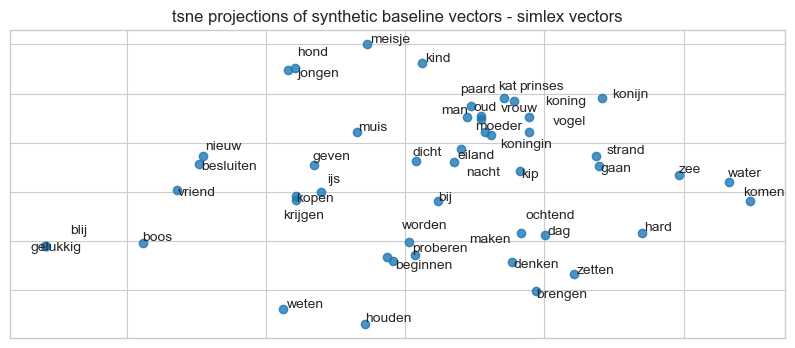

In [145]:
create_tsne_projections(model_syn_baseline, list_invocab_lemmas, title="tsne projections of synthetic baseline vectors - simlex vectors")

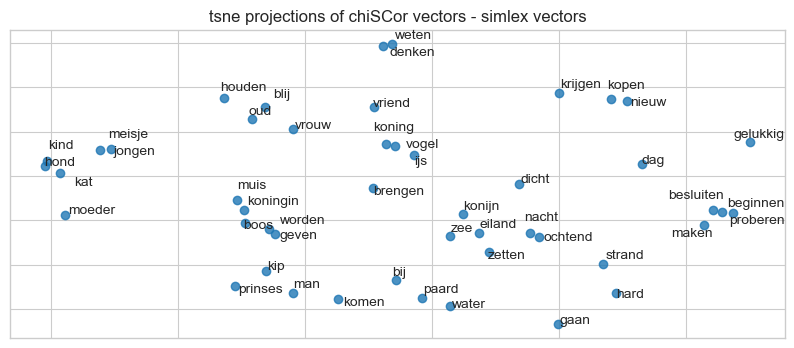

In [165]:
create_tsne_projections(model_CS, list_invocab_lemmas, title="tsne projections of chiSCor vectors - simlex vectors")

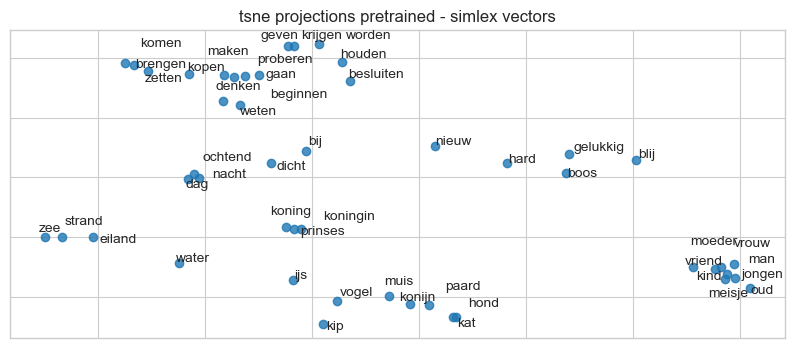

In [147]:
create_tsne_projections(model_syn_baseline, list_invocab_lemmas, use_pretrained=True, title="tsne projections pretrained - simlex vectors")

In [155]:
in_vocab_simlex_tuples = list(in_vocab_simlex[['lemma1', 'lemma2']].itertuples(index=False, name=None))

In [157]:
cosine_sim_CS, cosine_pretrained = compute_similarity(in_vocab_simlex_tuples, model_CS, nlp, use_pretrained=True, compare_method='pairwise')
stats.spearmanr(cosine_sim_CS, cosine_pretrained)

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/2015952861.py:2: DeprecationWarning: Please import `spearmanr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  stats.spearmanr(cosine_sim_CS, cosine_pretrained)


SignificanceResult(statistic=0.27365425658050746, pvalue=0.10123492215136892)

In [159]:
cosine_sim_syn, cosine_pretrained = compute_similarity(in_vocab_simlex_tuples, model_syn_baseline, nlp, use_pretrained=True, compare_method='pairwise')
stats.spearmanr(cosine_sim_syn, cosine_pretrained)

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/2997536148.py:2: DeprecationWarning: Please import `spearmanr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  stats.spearmanr(cosine_sim_syn, cosine_pretrained)


SignificanceResult(statistic=0.4726108608015176, pvalue=0.003139667786031065)

In [160]:
stats.spearmanr(cosine_sim_CS, cosine_sim_syn)

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/535916951.py:1: DeprecationWarning: Please import `spearmanr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  stats.spearmanr(cosine_sim_CS, cosine_sim_syn)


SignificanceResult(statistic=0.4171211761916053, pvalue=0.010216014813726425)

In [164]:
print(f'ChiSCor and simlex: {stats.spearmanr(cosine_sim_CS, list(in_vocab_simlex['SimLexScore']))}')
print(f'Pretrained and simlex: {stats.spearmanr(cosine_pretrained, list(in_vocab_simlex['SimLexScore']))}')
print(f'Synthetic baseline and simlex: {stats.spearmanr(cosine_sim_syn, list(in_vocab_simlex['SimLexScore']))}')

ChiSCor and simlex: SignificanceResult(statistic=0.6001897083234526, pvalue=8.611406382834035e-05)
Pretrained and simlex: SignificanceResult(statistic=0.5098411192791084, pvalue=0.001266932205003312)
Synthetic baseline and simlex: SignificanceResult(statistic=0.36506995494427313, pvalue=0.026301781000857703)


/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/2870292677.py:1: DeprecationWarning: Please import `spearmanr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  print(f'ChiSCor and simlex: {stats.spearmanr(cosine_sim_CS, list(in_vocab_simlex['SimLexScore']))}')
/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/2870292677.py:2: DeprecationWarning: Please import `spearmanr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  print(f'Pretrained and simlex: {stats.spearmanr(cosine_pretrained, list(in_vocab_simlex['SimLexScore']))}')
/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_23653/2870292677.py:3: DeprecationWarning: Please import `spearmanr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  print(f'Synthetic baseline and simlex: {stats.s

### Silhouette score

In [184]:
def retrieve_word_vectors(model, lemmas: List, *, use_pretrained=False):
    if use_pretrained:
        X = []
        for w in lemmas:
            X.append(nlp(w).vector)
        X = np.array(X)
    else:
        X = model.wv[lemmas]

    return X

In [224]:
# find pos with noun
labels = []
tokenized_labels = []
label2i = {'N': 0, 'A': 1, 'V': 2}
i2labels = {0: 'noun', 1: 'adjective', 2: 'verb'}
for word in list_invocab_lemmas:
    label = in_vocab_simlex['POS'][in_vocab_simlex['lemma1'] == word]
    if label.empty:
        label = in_vocab_simlex['POS'][in_vocab_simlex['lemma2'] == word]
    labels.append(label)
    tokenized_labels.append(label2i[label.iloc[0]])

In [185]:
ChiSCor_vectors = retrieve_word_vectors(model_CS, list_invocab_lemmas)
syn_vectors = retrieve_word_vectors(model_syn_baseline, list_invocab_lemmas)
pretrained_vec = retrieve_word_vectors(nlp, list_invocab_lemmas, use_pretrained=True)

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples

chiscor_sil = silhouette_score(ChiSCor_vectors, tokenized_labels)
syn_sil = silhouette_score(syn_vectors, tokenized_labels)
pretrained_sil = silhouette_score(pretrained_vec, tokenized_labels)

In [237]:
def plot_silhouette_samples(vectors, labels, i2labels, title="Silhouette Plot"):
    # Calculate Silhouette Samples
    silhouette_vals = silhouette_samples(vectors, labels)

    # Plot Silhouette Scores 
    y_lower = 10
    labels = np.array(labels)
    for i in range(3):  # Number of clusters
        cluster_sil_vals = silhouette_vals[labels == i]
        cluster_sil_vals.sort()
        y_upper = y_lower + len(cluster_sil_vals)

        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil_vals, alpha=0.7)
        plt.text(-0.05, y_lower + 0.5 * len(cluster_sil_vals), i2labels[i])
        y_lower = y_upper + 10

    plt.xticks(np.arange(-.25, .35, step=.05))
    sil = silhouette_score(vectors, labels)
    plt.axvline(x=sil, color="red", linestyle="--")
    plt.title(title)
    plt.xlabel("Silhouette Coefficient")
    plt.ylabel("Cluster")
    plt.show()

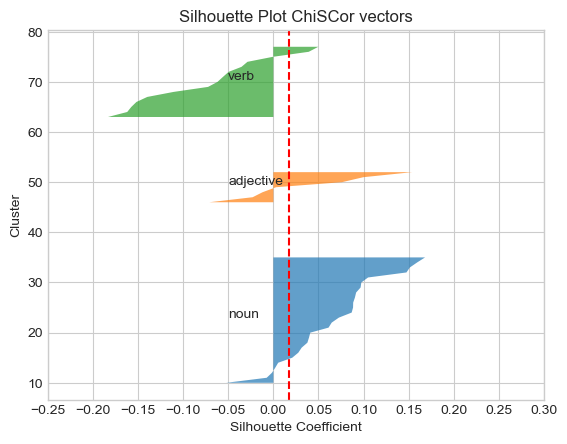

In [238]:
plot_silhouette_samples(ChiSCor_vectors, tokenized_labels, i2labels, title="Silhouette Plot ChiSCor vectors")


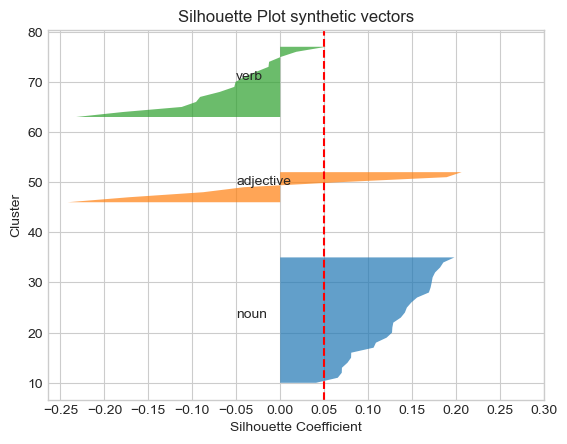

In [239]:
plot_silhouette_samples(syn_vectors, tokenized_labels, i2labels, title="Silhouette Plot synthetic vectors")

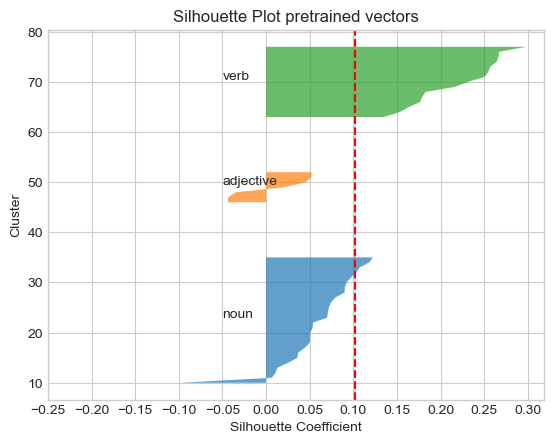

In [240]:
plot_silhouette_samples(pretrained_vec, tokenized_labels, i2labels, title="Silhouette Plot pretrained vectors")

## Storyarc analysis

In [73]:
class LocalContextuality:
    """
    Computes local contextuality as the average cosine similarity between
    consecutive sentences in a text.

    Parameters
    ----------
    nlp : spaCy Language
        Used for sentence segmentation.
    model_path : str
        Path or HuggingFace model ID for sentence embeddings.
        Default: "bert-base-uncased".
    min_items : int
        Minimum number of sentences required to compute a score. If fewer, returns 0.0.
    """

    def __init__(self, nlp, model_path: str = "bert-base-uncased", min_items: int = 2):
        self.nlp = nlp
        self.model_path = model_path
        self.model = SentenceTransformer(model_path)
        self.min_items = min_items
    
    def get_content_words_per_sentence(self, sent):
        content_words = []
        for token in sent:
            if str(token.pos_) in ['ADV', 'VERB', 'NOUN', 'ADJ']:
                content_words.append(token.lemma_)

        return f" ".join(content_words)
    
    def get_content_words_per_story(self, story):
        content_words_per_sent = []
        for sent in story:
            temp = self.get_content_words_per_sentence(sent)

            if len(temp) != 0:
                content_words_per_sent.append(temp)
        
        return content_words_per_sent

    def _calculate_lc(self, sents):
        if len(list(sents)) < self.min_items:
            return 0.0

        try:
            # Encode all sentences
            # content_sents = self.get_content_words_per_story(sents)
            # for i in range(1, len(content_sents)):
            #     print(f'({i-1, i}) {content_sents[i-1]}; {content_sents[i]}')
            X = self.model.encode(sents, convert_to_numpy=True, normalize_embeddings=True)

            # Cosine similarity of consecutive pairs
            sims = []
            for i in range(len(X) - 1):
                sims.append(float(np.dot(X[i], X[i + 1])))

            return float(np.mean(sims)) if sims else 0.0, sims

        except Exception:
            raise
            return 0.0

    def evaluate(self, text: str) -> float:
        #sents = list(self.nlp(text).sents)
        sents = list(map(str, list(self.nlp(text).sents)))

        return self._calculate_lc(sents)

In [74]:
LC = LocalContextuality(nlp, 'jegormeister/bert-base-dutch-cased')

In [75]:
df_chiscor['story_raw'].iloc[2]

"d'r waren eens handen. \nalleen die gingen op de computer iets typen anders kon je niet lezen. \nhij wou hoe moet je lezen en schrijven. \nalleen hij typte het helemaal fout. \nhij schreef A A N D E E. \nrara wat staat er nu?"

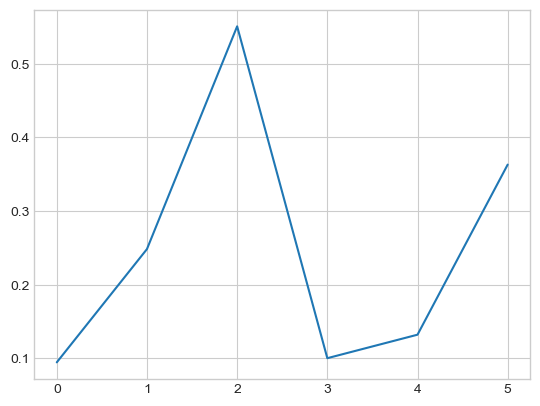

In [76]:
example = df_chiscor['story_raw'].iloc[2]

plt.plot(LC.evaluate(example)[1])
